# Digital Payments Settlement Latency & Merchant Churn Analytics
### Group 03 — Programming for Analytics · Comprehensive Group Capstone Project & Live Code Defense

**Engagement framing:** Senior Analytics Advisory Team reporting to the **COO** and **Head of Merchant Acquiring**
of a digital payments aggregator processing 530k+ transaction volume across UPI, Cards and
NetBanking for 8,500+ merchants (revenue = Merchant Discount Rate on processed volume).

| # | Team Member | SAP ID | Roll Number | Email ID | % Contribution |
|---|-------------|--------|-------------|----------|----------------|
| 1 | *Member A (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 2 | *Member B (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 3 | *Member C (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 4 | *Member D (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 5 | *Member E (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 6 | *Member F (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 7 | *Member G (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |

**Data:** `payments_analytics.db` (SQLite 3) — 5 relational tables (3 dimensions, 2 facts), sole data source.
**Pipeline shape:** `Relational Data → Data Quality → Descriptive → Diagnostic → Recommendations → Impact`.
**Architecture:** **SQL extracts** the five tables once into labelled DataFrames (`df_merchants`, `df_banks`,
`df_methods`, `df_txns`, `df_settlements`); **pandas does all the work afterwards** — cleaning, integrity
validation, EDA, aggregation, diagnostics and feature engineering.
**Libraries:** `numpy`, `pandas`, `matplotlib`, `seaborn` (+ Python's built-in `sqlite3` driver).
**Notebook map:** setup → SQL extraction → integrity → data quality → pandas prep → descriptive baseline →
Part 1 gateway diagnostics (KBQ 1–2) → Part 2 settlement & churn (KBQ 3–4) → Part 3 smart-routing lift (KBQ 5–6) →
Part 4 revenue economics (KBQ 7–8) → findings, 5 recommendations & executive summary.

**How to run:** keep this notebook beside `payments_analytics.db` and run *Restart Kernel → Run All Cells*.
Python ≥ 3.13 with `numpy`, `pandas`, `matplotlib`, `seaborn` (see `requirements.txt`; uv users: `uv sync`).
All paths are relative — no configuration needed.

## 1 · Setup & Configuration
One environment cell: imports, display/plot settings, the `run_sql` helper over Python's built-in
`sqlite3` driver, and small formatting utilities reused throughout.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")          # keep outputs clean for evaluation
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9.5, 4.2),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 9.5,
})

# --- database connection (RELATIVE path — the .db must sit beside this notebook) ---
DB_PATH = Path("payments_analytics.db")
assert DB_PATH.exists(), f"Database not found at {DB_PATH.resolve()} — keep payments_analytics.db beside this notebook."
CONN = sqlite3.connect(DB_PATH)


def run_sql(sql: str) -> pd.DataFrame:
    """Extract data from the SQLite database into a DataFrame (extraction layer only)."""
    return pd.read_sql_query(sql, CONN)


TIER_ORDER = ["ENTERPRISE", "MID_MARKET", "SMB"]
TIER_COLORS = {"ENTERPRISE": "#1f77b4", "MID_MARKET": "#ff7f0e", "SMB": "#d62728"}


def success_rate(status: pd.Series) -> float:
    """Transaction success rate (%) = SUCCESS attempts / all attempts x 100."""
    return status.eq("SUCCESS").mean() * 100


def label_bars(ax, fmt="{:,.0f}"):
    """Value labels on top of vertical bars."""
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8, xytext=(0, 2),
                    textcoords="offset points")


def inrm(x, decimals=2):
    """Format an INR amount in millions."""
    return f"Rs {x/1e6:,.{decimals}f}M"


print("Environment ready — pandas", pd.__version__, "| seaborn", sns.__version__,
      "| DB:", DB_PATH.name)

Environment ready — pandas 3.0.5 | seaborn 0.13.2 | DB: payments_analytics.db


## 2 · SQL Extraction — the Five Tables into Labelled DataFrames
The database is a star-like schema: **3 dimensions** (`dim_merchants`, `dim_issuing_banks`,
`dim_payment_methods`) → **2 facts** (`fact_payment_transactions`, `fact_merchant_settlements`),
all FKs `ON DELETE RESTRICT` (1:N from each dimension into the facts; N:M analysis arises through the
facts bridging merchant × bank × payment method).

SQL's job here is **extraction only**: each table is pulled once with an explicit column list into an
appropriately-labelled DataFrame. Everything after this block — cleaning, integrity, EDA, aggregation —
happens in pandas.

In [2]:
# --- dimensions (small lookup tables) ---
df_merchants = run_sql("""
    SELECT merchant_id, business_name, mcc_category, onboarding_date, merchant_tier,
           settlement_cycle_sla, is_active, churn_date, churn_reason
    FROM dim_merchants
""")
df_banks = run_sql("""
    SELECT bank_id, bank_name, bank_code, tier, base_network_reliability_pct
    FROM dim_issuing_banks
""")
df_methods = run_sql("""
    SELECT payment_method_id, payment_channel, network_provider, mdr_rate_pct
    FROM dim_payment_methods
""")
print("dimensions loaded:",
      [f"df_merchants {df_merchants.shape}", f"df_banks {df_banks.shape}", f"df_methods {df_methods.shape}"])

dimensions loaded: ['df_merchants (8500, 9)', 'df_banks (12, 5)', 'df_methods (16, 4)']


In [3]:
# --- facts (transaction log + settlement ledger) ---
df_txns = run_sql("""
    SELECT txn_id, merchant_id, bank_id, payment_method_id, txn_timestamp, amount_inr,
           status, error_code, latency_ms, is_routed_via_dynamic_sla
    FROM fact_payment_transactions
""")
df_settlements = run_sql("""
    SELECT settlement_id, merchant_id, settlement_batch_date, gross_volume_inr, net_mdr_deducted_inr,
           net_settled_amount_inr, expected_settlement_date, actual_settlement_date,
           settlement_delay_days, sla_breach_flag
    FROM fact_merchant_settlements
""")

# --- typing pass (pandas cleaning): real datetimes for every date/datetime column ---
df_txns["txn_timestamp"] = pd.to_datetime(df_txns["txn_timestamp"], format="%Y-%m-%d %H:%M:%S")
for col in ["settlement_batch_date", "expected_settlement_date", "actual_settlement_date"]:
    df_settlements[col] = pd.to_datetime(df_settlements[col])
for col in ["onboarding_date", "churn_date"]:
    df_merchants[col] = pd.to_datetime(df_merchants[col])

frames = {"df_merchants": df_merchants, "df_banks": df_banks, "df_methods": df_methods,
          "df_txns": df_txns, "df_settlements": df_settlements}
frame_summary = pd.DataFrame([
    {"dataframe": name, "rows": df.shape[0], "cols": df.shape[1],
     "memory_mb": round(df.memory_usage(deep=True).sum() / 1e6, 1)}
    for name, df in frames.items()
])
display(frame_summary)
print(f"Total in-memory footprint: {frame_summary['memory_mb'].sum():,.0f} MB — comfortably in pandas' wheelhouse.")

,dataframe,rows,cols,memory_mb
0,df_merchants,8500,9,3.1
1,df_banks,12,5,0.0
2,df_methods,16,4,0.0
3,df_txns,530000,10,202.3
4,df_settlements,125000,10,23.4


Total in-memory footprint: 229 MB — comfortably in pandas' wheelhouse.


## 3 · Relational Integrity Validation (in pandas)
Before trusting joins we prove the relational contract holds **inside pandas**: no duplicate primary
keys, no orphaned foreign keys (checked with left-merge + `_merge` indicator — no Cartesian inflation),
and the settlement ledger identity `net = gross − MDR`. Join fan-out is quantified to document the
1:N / N:M structure.

In [4]:
# --- row counts & declared FK relationships (schema introspection via SQL) ---
fk_rows = []
for fact in ["fact_payment_transactions", "fact_merchant_settlements"]:
    fk = run_sql(f"PRAGMA foreign_key_list({fact})")
    for _, r in fk.iterrows():
        fk_rows.append({"child_table": fact, "fk_column": r["from"],
                        "parent_table": r["table"], "parent_pk": r["to"]})
fk_map = pd.DataFrame(fk_rows)
display(fk_map)

# --- PK uniqueness (no duplicate primary keys) ---
pk_specs = {"df_merchants": ("merchant_id", df_merchants), "df_banks": ("bank_id", df_banks),
            "df_methods": ("payment_method_id", df_methods), "df_txns": ("txn_id", df_txns),
            "df_settlements": ("settlement_id", df_settlements)}
dup_pk = pd.DataFrame([
    {"dataframe": name, "duplicate_pks": int(df.duplicated(subset=[key]).sum())}
    for name, (key, df) in pk_specs.items()
])
display(dup_pk)
assert dup_pk["duplicate_pks"].sum() == 0, "Duplicate primary keys found!"

,child_table,fk_column,parent_table,parent_pk
0,fact_payment_transactions,payment_method_id,dim_payment_methods,payment_method_id
1,fact_payment_transactions,bank_id,dim_issuing_banks,bank_id
2,fact_payment_transactions,merchant_id,dim_merchants,merchant_id
3,fact_merchant_settlements,merchant_id,dim_merchants,merchant_id


,dataframe,duplicate_pks
0,df_merchants,0
1,df_banks,0
2,df_methods,0
3,df_txns,0
4,df_settlements,0


In [5]:
# --- FK orphan checks: left-merge with indicator, count unmatched children ---
def orphan_count(child: pd.DataFrame, key: str, parent: pd.DataFrame, parent_key: str) -> int:
    merged = child[[key]].drop_duplicates().merge(
        parent[[parent_key]], left_on=key, right_on=parent_key, how="left", indicator=True)
    return int((merged["_merge"] == "left_only").sum())


orphan_checks = pd.DataFrame([
    {"relationship": "df_txns.merchant_id -> df_merchants",
     "orphans": orphan_count(df_txns, "merchant_id", df_merchants, "merchant_id")},
    {"relationship": "df_txns.bank_id -> df_banks",
     "orphans": orphan_count(df_txns, "bank_id", df_banks, "bank_id")},
    {"relationship": "df_txns.payment_method_id -> df_methods",
     "orphans": orphan_count(df_txns, "payment_method_id", df_methods, "payment_method_id")},
    {"relationship": "df_settlements.merchant_id -> df_merchants",
     "orphans": orphan_count(df_settlements, "merchant_id", df_merchants, "merchant_id")},
])
display(orphan_checks)
assert orphan_checks["orphans"].sum() == 0, "Orphaned FK records found!"

# --- settlement ledger identity: net_settled = gross - MDR ---
ledger_gap = (df_settlements["net_settled_amount_inr"]
              - (df_settlements["gross_volume_inr"] - df_settlements["net_mdr_deducted_inr"])).abs()
bad_ledger = int((ledger_gap > 0.01).sum())
print(f"Ledger identity violations (net ≠ gross − MDR, tolerance Rs 0.01): {bad_ledger}")
assert bad_ledger == 0, "Settlement ledger identity broken!"

# --- join fan-out: facts bridge dimensions 1:N; merchant x bank x method meet in the fact (N:M) ---
txn_fan = df_txns.groupby("merchant_id").agg(
    txns=("txn_id", "size"), banks=("bank_id", "nunique"), methods=("payment_method_id", "nunique"))
set_fan = df_settlements.groupby("merchant_id").size()
fanout = pd.DataFrame({
    "relationship": ["txns per merchant", "settlements per merchant",
                     "distinct banks per merchant", "distinct methods per merchant"],
    "max": [txn_fan["txns"].max(), set_fan.max(), txn_fan["banks"].max(), txn_fan["methods"].max()],
    "avg": [txn_fan["txns"].mean(), set_fan.mean(), txn_fan["banks"].mean(), txn_fan["methods"].mean()],
})
display(fanout)
print("VERDICT: clean star schema — PKs unique, zero orphans, ledger identity holds; facts bridge "
      "dimensions 1:N with N:M analysis available merchant x bank x method.")

,relationship,orphans
0,df_txns.merchant_id -> df_merchants,0
1,df_txns.bank_id -> df_banks,0
2,df_txns.payment_method_id -> df_methods,0
3,df_settlements.merchant_id -> df_merchants,0


Ledger identity violations (net ≠ gross − MDR, tolerance Rs 0.01): 0


,relationship,max,avg
0,txns per merchant,91,62.352941
1,settlements per merchant,73,49.662296
2,distinct banks per merchant,12,11.932471
3,distinct methods per merchant,16,12.985882


VERDICT: clean star schema — PKs unique, zero orphans, ledger identity holds; facts bridge dimensions 1:N with N:M analysis available merchant x bank x method.


## 4 · Data Quality Audit & Treatment Decisions (in pandas)
NULL patterns, categorical domain conformance, date-range coverage and value-plausibility bounds —
all checked vectorised on the extracted frames. Every **material decision** taken later in the
notebook is justified by a check here.

In [6]:
# --- NULL audit (all frames, only columns with NULLs are shown) ---
null_rows = []
for name, df in frames.items():
    nulls = df.isnull().sum()
    for col in nulls[nulls > 0].index:
        null_rows.append({"dataframe": name, "column": col,
                          "nulls": int(nulls[col]), "null_pct": 100 * nulls[col] / len(df)})
nulls_df = pd.DataFrame(null_rows).sort_values("null_pct", ascending=False)
display(nulls_df if len(nulls_df) else pd.DataFrame({"result": ["no NULLs anywhere"]}))

# churn fields are NULL **by design** for active merchants — verify the pattern:
churn_nulls = (df_merchants.assign(merchant_state=np.where(df_merchants["is_active"] == 1, "active", "churned"))
               .groupby("merchant_state")
               .agg(merchants=("merchant_id", "size"),
                    churn_date_nulls=("churn_date", lambda s: int(s.isnull().sum())),
                    churn_reason_nulls=("churn_reason", lambda s: int(s.isnull().sum()))))
display(churn_nulls)

,dataframe,column,nulls,null_pct
0,df_merchants,churn_date,7122,83.788235
1,df_merchants,churn_reason,7122,83.788235


,merchants,churn_date_nulls,churn_reason_nulls
merchant_state,,,
active,7122,7122,7122
churned,1378,0,0


In [7]:
# --- categorical domain conformance + pairing logic (vectorised boolean masks) ---
DOMAINS = {
    "status": {"SUCCESS", "FAILED", "USER_DROPPED", "TIMEOUT"},
    "error_code": {"ERR_NONE", "ERR_BANK_TIMEOUT", "ERR_INSUFFICIENT_FUNDS",
                   "ERR_NPCI_DEGRADED", "ERR_AUTH_FAILED", "ERR_SWITCH_UNAVAILABLE"},
}
domain_checks = pd.DataFrame([
    {"check": "txn status in 4-value domain",
     "violations": int((~df_txns["status"].isin(DOMAINS["status"])).sum())},
    {"check": "txn error_code in declared 6-value domain",
     "violations": int((~df_txns["error_code"].isin(DOMAINS["error_code"])).sum())},
    {"check": "SUCCESS <=> ERR_NONE pairing",
     "violations": int((df_txns["status"].eq("SUCCESS") != df_txns["error_code"].eq("ERR_NONE")).sum())},
    {"check": "sla_breach_flag in {0,1}",
     "violations": int((~df_settlements["sla_breach_flag"].isin([0, 1])).sum())},
    {"check": "settlement_delay_days >= 0",
     "violations": int((df_settlements["settlement_delay_days"] < 0).sum())},
    {"check": "latency_ms in plausible range (250-12000)",
     "violations": int((~df_txns["latency_ms"].between(250, 12000)).sum())},
    {"check": "amount_inr > 0", "violations": int((df_txns["amount_inr"] <= 0).sum())},
    {"check": "merchant tier in {ENTERPRISE, MID_MARKET, SMB}",
     "violations": int((~df_merchants["merchant_tier"].isin(TIER_ORDER)).sum())},
    {"check": "churn_reason NULL exactly when active",
     "violations": int((df_merchants["is_active"].eq(1) != df_merchants["churn_reason"].isnull()).sum())},
    {"check": "is_active consistent with churn_date",
     "violations": int((df_merchants["churn_date"].notnull() & df_merchants["is_active"].eq(1)).sum())},
])
display(domain_checks)
assert domain_checks["violations"].sum() == 0, "Domain violations found!"

# --- temporal coverage ---
ranges = pd.DataFrame({
    "series": ["transactions", "settlement batches", "settlement actual dates", "merchant onboarding"],
    "first": [df_txns["txn_timestamp"].min(), df_settlements["settlement_batch_date"].min(),
              df_settlements["actual_settlement_date"].min(), df_merchants["onboarding_date"].min()],
    "last": [df_txns["txn_timestamp"].max(), df_settlements["settlement_batch_date"].max(),
             df_settlements["actual_settlement_date"].max(), df_merchants["onboarding_date"].max()],
})
display(ranges)

# late-settling batches: actual settlement date can spill past 2024-12 (stub month)
settle_months = df_settlements["actual_settlement_date"].dt.strftime("%Y-%m")
spillover = settle_months.value_counts().sort_index().tail(3).rename_axis("settle_month").reset_index(name="batches")
display(spillover)

,check,violations
0,txn status in 4-value domain,0
1,txn error_code in declared 6-value domain,0
2,SUCCESS <=> ERR_NONE pairing,0
3,"sla_breach_flag in {0,1}",0
4,settlement_delay_days >= 0,0
5,latency_ms in plausible range (250-12000),0
6,amount_inr > 0,0
7,"merchant tier in {ENTERPRISE, MID_MARKET, SMB}",0
8,churn_reason NULL exactly when active,0
9,is_active consistent with churn_date,0


,series,first,last
0,transactions,2023-07-01 00:00:24,2024-12-31 23:58:13
1,settlement batches,2023-07-01 00:00:00,2024-12-31 00:00:00
2,settlement actual dates,2023-07-01 00:00:00,2025-01-07 00:00:00
3,merchant onboarding,2023-01-01 00:00:00,2024-06-30 00:00:00


,settle_month,batches
0,2024-11,6703
1,2024-12,7019
2,2025-01,438


In [8]:
# --- documented quality decisions ---
from IPython.display import Markdown, display as ipy_display

stub_month = spillover["settle_month"].iloc[-1]
stub_batches = int(spillover["batches"].iloc[-1])

# settlement coverage — does partial coverage select on churn?
covered_ids = set(df_settlements["merchant_id"])
df_merchants["settlement_coverage"] = np.where(df_merchants["merchant_id"].isin(covered_ids),
                                               "covered", "not covered")
parity = (df_merchants.groupby("settlement_coverage")
          .agg(merchants=("merchant_id", "size"),
               churn_pct=("churn_date", lambda s: s.notnull().mean()))
          .reset_index())
parity["churn_pct"] = parity["churn_pct"] * 100

ipy_display(Markdown(f"""\
**Data-quality findings & treatment decisions**

| # | Finding (verified above) | Decision & rationale |
|---|--------------------------|----------------------|
| Q1 | Only NULLs in the entire DB: `churn_date` / `churn_reason` for the {int(churn_nulls.loc['active', 'merchants']):,} active merchants | **Keep as-is** — structurally meaningful NULLs (active merchants never churned). Imputation would be wrong. |
| Q2 | Zero duplicate PKs, zero FK orphans, settlement ledger identity exact | No de-duplication or repair needed; keyed merges are safe (no Cartesian inflation risk). |
| Q3 | `status` uses the 4-value domain incl. `USER_DROPPED`; `SUCCESS ⇔ ERR_NONE` pairs perfectly | Treat the dictionary's 4-value domain as authoritative. Success rate = SUCCESS ÷ all attempts (per brief). |
| Q4 | Settlement `actual_settlement_date` spills into a **stub month {stub_month}** ({stub_batches:,} late-settled T+2/T+3 batches) | **Keep rows** (valid settlements) but cut monthly trend series at 2024-12; annualization uses the clean 18-month window 2023-07 → 2024-12. |
| Q5 | Latency bounded 250–12,000 ms by design; amounts strictly positive; breach flags binary; delay days ≥ 0 | Bounds respected — no winsorization applied (values are physically plausible). |
| Q6 | Settlement fact covers only **{int(parity.loc[parity['settlement_coverage'] == 'covered', 'merchants'].iloc[0]):,} of {int(parity['merchants'].sum()):,} merchants**; covered vs uncovered churn nearly identical ({parity.loc[parity['settlement_coverage'] == 'covered', 'churn_pct'].iloc[0]:.2f}% vs {parity.loc[parity['settlement_coverage'] == 'not covered', 'churn_pct'].iloc[0]:.2f}%) | Exposure→churn analysis is run **within the covered population** (Part 2/Part 4) — coverage does not select on churn, so comparisons remain unbiased; the gap is stated wherever settlement-based figures appear. |"""))

**Data-quality findings & treatment decisions**

| # | Finding (verified above) | Decision & rationale |
|---|--------------------------|----------------------|
| Q1 | Only NULLs in the entire DB: `churn_date` / `churn_reason` for the 7,122 active merchants | **Keep as-is** — structurally meaningful NULLs (active merchants never churned). Imputation would be wrong. |
| Q2 | Zero duplicate PKs, zero FK orphans, settlement ledger identity exact | No de-duplication or repair needed; keyed merges are safe (no Cartesian inflation risk). |
| Q3 | `status` uses the 4-value domain incl. `USER_DROPPED`; `SUCCESS ⇔ ERR_NONE` pairs perfectly | Treat the dictionary's 4-value domain as authoritative. Success rate = SUCCESS ÷ all attempts (per brief). |
| Q4 | Settlement `actual_settlement_date` spills into a **stub month 2025-01** (438 late-settled T+2/T+3 batches) | **Keep rows** (valid settlements) but cut monthly trend series at 2024-12; annualization uses the clean 18-month window 2023-07 → 2024-12. |
| Q5 | Latency bounded 250–12,000 ms by design; amounts strictly positive; breach flags binary; delay days ≥ 0 | Bounds respected — no winsorization applied (values are physically plausible). |
| Q6 | Settlement fact covers only **2,517 of 8,500 merchants**; covered vs uncovered churn nearly identical (16.09% vs 16.26%) | Exposure→churn analysis is run **within the covered population** (Part 2/Part 4) — coverage does not select on churn, so comparisons remain unbiased; the gap is stated wherever settlement-based figures appear. |

## 5 · Analytical Preparation (pandas feature engineering)
Calendar keys (`month`, `hour`, batch/settle months), churn flags, and the **merchant-level breach
exposure frame** `df_merchant_exposure` — one labelled DataFrame that Part 2 (churn) and Part 4
(protected volume) reuse so both share a single exposure definition.

In [9]:
# --- calendar keys & churn flag ---
df_txns["month"] = df_txns["txn_timestamp"].dt.strftime("%Y-%m")
df_txns["hour"] = df_txns["txn_timestamp"].dt.hour
df_settlements["batch_month"] = df_settlements["settlement_batch_date"].dt.strftime("%Y-%m")
df_settlements["settle_month"] = df_settlements["actual_settlement_date"].dt.strftime("%Y-%m")
df_merchants["is_churned"] = df_merchants["churn_date"].notna()

# --- settlement coverage by tier (merchants with/without settlements) ---
coverage = (df_merchants.groupby(["merchant_tier", "settlement_coverage"])
            .agg(merchants=("merchant_id", "size"), churn_pct=("is_churned", "mean"))
            .reset_index())
coverage["churn_pct"] = coverage["churn_pct"] * 100
display(coverage.pivot(index="merchant_tier", columns="settlement_coverage",
                       values=["merchants", "churn_pct"]).reindex(TIER_ORDER))
print("Coverage by tier. As verified in the data-quality block, covered vs not-covered churn rates "
      "are near-identical, so exposure analysis within the covered population is unbiased.")

merchants              churn_pct            
settlement_coverage   covered not covered    covered not covered
merchant_tier                                                   
ENTERPRISE              197.0       499.0   2.030457    3.607214
MID_MARKET              677.0      1672.0   5.908419    8.014354
SMB                    1643.0      3812.0  21.972002   21.537251

Coverage by tier. As verified in the data-quality block, covered vs not-covered churn rates are near-identical, so exposure analysis within the covered population is unbiased.


In [10]:
# --- merchant-level settlement exposure (the shared exposure definition) ---
per_merchant = (df_settlements.groupby("merchant_id")
                .agg(batches=("settlement_id", "size"),
                     breach_rate=("sla_breach_flag", "mean"),
                     gpv_inr=("gross_volume_inr", "sum"),
                     mdr_inr=("net_mdr_deducted_inr", "sum"))
                .reset_index())
df_merchant_exposure = per_merchant.merge(df_merchants, on="merchant_id")

rate = df_merchant_exposure["breach_rate"]
df_merchant_exposure["breach_bucket"] = np.select(
    [rate == 0, rate <= 0.10, rate <= 0.25], ["0%", "0-10%", "10-25%"], default=">25%")
BUCKET_ORDER = ["0%", "0-10%", "10-25%", ">25%"]

print(f"df_merchant_exposure: {df_merchant_exposure.shape[0]:,} merchants x {df_merchant_exposure.shape[1]} cols "
      f"(covered population only).")
display(df_merchant_exposure["breach_bucket"].value_counts().reindex(BUCKET_ORDER).rename_axis("breach_bucket").reset_index(name="merchants"))

df_merchant_exposure: 2,517 merchants x 16 cols (covered population only).


,breach_bucket,merchants
0,0%,4
1,0-10%,477
2,10-25%,941
3,>25%,1095


## 6 · Descriptive Baseline — the Business at a Glance
Scale, success rate, latency, settlement performance, revenue and churn in one KPI band, then the monthly
trajectory and channel mix that frame every diagnostic that follows.

In [11]:
# --- KPI band (computed from the extracted frames) ---
total_txns = len(df_txns)
kpi = {
    "total_txns": total_txns,
    "success_rate_pct": success_rate(df_txns["status"]),
    "avg_latency_ms": df_txns["latency_ms"].mean(),
    "gmv_attempted_m": df_txns["amount_inr"].sum() / 1e6,
    "settlement_batches": len(df_settlements),
    "sla_breach_rate_pct": df_settlements["sla_breach_flag"].mean() * 100,
    "realized_mdr_inr": df_settlements["net_mdr_deducted_inr"].sum(),
    "merchants": len(df_merchants),
    "churn_rate_pct": df_merchants["is_churned"].mean() * 100,
}
kpi_display = pd.DataFrame({"value": pd.Series(kpi)})
kpi_display.index = ["transactions (18 mo)", "success rate %", "avg latency ms",
                     "attempted GMV (Rs M)", "settlement batches", "SLA breach rate %",
                     "realized MDR (Rs)", "merchants", "merchant churn rate %"]
display(kpi_display)

# --- monthly trend & channel mix ---
monthly = (df_txns.groupby("month")
           .agg(txns=("txn_id", "size"), sr_pct=("status", success_rate),
                avg_latency_ms=("latency_ms", "mean"))
           .reset_index())

df_txns_methods = df_txns.merge(df_methods, on="payment_method_id")
df_success = df_txns_methods[df_txns_methods["status"] == "SUCCESS"].copy()
df_success["mdr_amount_inr"] = df_success["amount_inr"] * df_success["mdr_rate_pct"] / 100
channel = (df_success.groupby("payment_channel")
           .agg(gmv_success_m=("amount_inr", "sum"), txns=("txn_id", "size"),
                mdr_potential_m=("mdr_amount_inr", "sum"))
           .reset_index())
channel["gmv_success_m"] = channel["gmv_success_m"] / 1e6
channel["mdr_potential_m"] = channel["mdr_potential_m"] / 1e6
channel = channel.sort_values("gmv_success_m", ascending=False)
display(channel)

,value
transactions (18 mo),5.300000e+05
success rate %,8.369113e+01
avg latency ms,1.367124e+03
attempted GMV (Rs M),8.720390e+02
settlement batches,1.250000e+05
SLA breach rate %,2.843200e+01
realized MDR (Rs),2.831174e+06
merchants,8.500000e+03
merchant churn rate %,1.621176e+01


,payment_channel,gmv_success_m,txns,mdr_potential_m
3,UPI,400.759762,243752,0.000000
0,CREDIT_CARD,147.034944,88924,2.530281
1,DEBIT_CARD,102.598128,62089,0.850925
2,NET_BANKING,51.150579,31174,0.778371
4,WALLET,28.703675,17624,0.322833


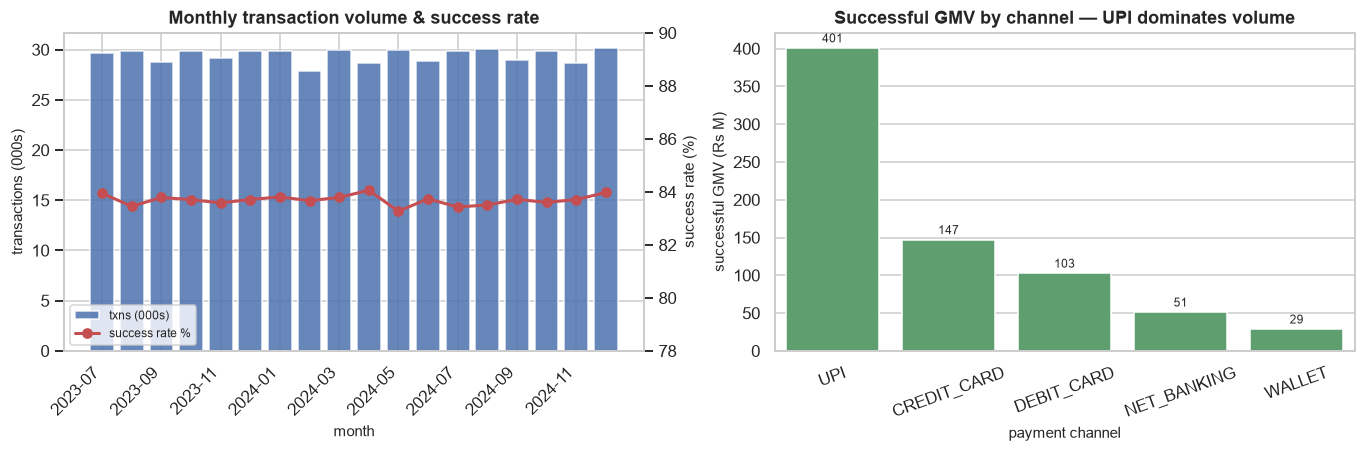

Baseline read: 530,000 attempts at 83.69% success; ~28.4% of settlement batches breach SLA; 16.21% of merchants have churned. UPI carries 55% of successful GMV but earns 0% MDR — revenue lives in cards/NetBanking.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

x = np.arange(len(monthly))
ax1.bar(x, monthly["txns"] / 1e3, color="#4c72b0", alpha=0.85, label="txns (000s)")
ax1.set_xticks(x[::2]); ax1.set_xticklabels(monthly["month"][::2], rotation=45, ha="right")
ax1.set_ylabel("transactions (000s)"); ax1.set_xlabel("month")
ax2b = ax1.twinx()
ax2b.plot(x, monthly["sr_pct"], color="#c44e52", marker="o", lw=2, label="success rate %")
ax2b.set_ylim(78, 90); ax2b.set_ylabel("success rate (%)"); ax2b.grid(False)
ax1.set_title("Monthly transaction volume & success rate")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

sns.barplot(data=channel, x="payment_channel", y="gmv_success_m", hue="payment_channel",
            palette=["#55a868"] * len(channel), legend=False, ax=ax2, errorbar=None)
label_bars(ax2, "{:,.0f}")
ax2.set_ylabel("successful GMV (Rs M)"); ax2.set_xlabel("payment channel")
ax2.set_title("Successful GMV by channel — UPI dominates volume")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

upi_share = channel.loc[channel["payment_channel"] == "UPI", "gmv_success_m"].iloc[0] / channel["gmv_success_m"].sum() * 100
print(f"Baseline read: {kpi['total_txns']:,} attempts at {kpi['success_rate_pct']:.2f}% success; "
      f"~{kpi['sla_breach_rate_pct']:.1f}% of settlement batches breach SLA; "
      f"{kpi['churn_rate_pct']:.2f}% of merchants have churned. "
      f"UPI carries {upi_share:.0f}% of successful GMV but earns 0% MDR — revenue lives in cards/NetBanking.")

## 7 · Part 1 — KBQ 1: Issuing-Bank Latency & Switch-Degradation Profiling
Which of the 12 issuing banks drive latency and timeouts, how do PSU banks compare with private banks,
and where in the day does the switch infrastructure crack? A **p95 latency** (one `groupby().quantile()`
call in pandas) and a **spike share** (attempts ≥ 10,000 ms — the brief's 'severe switch degradation'
threshold) quantify the tails.

In [13]:
# --- transactions enriched with bank attributes (labelled join frame) ---
df_txns_banks = df_txns.merge(df_banks, on="bank_id")
df_txns_banks["is_timeout"] = df_txns_banks["status"].eq("TIMEOUT")
df_txns_banks["is_spike"] = df_txns_banks["latency_ms"] >= 10_000

# --- per-bank profile ---
bank_profile = (df_txns_banks.groupby(["bank_name", "tier"])
                .agg(txns=("txn_id", "size"), sr_pct=("status", success_rate),
                     timeout_pct=("is_timeout", "mean"), avg_latency_ms=("latency_ms", "mean"),
                     spike_pct=("is_spike", "mean"))
                .reset_index())
bank_profile[["timeout_pct", "spike_pct"]] = bank_profile[["timeout_pct", "spike_pct"]] * 100

bank_p95 = (df_txns_banks.groupby("bank_name")["latency_ms"].quantile(0.95)
            .rename("p95_latency_ms").reset_index())
bank_profile = bank_profile.merge(bank_p95, on="bank_name").sort_values("avg_latency_ms", ascending=False)
display(bank_profile)

# --- PSU vs Private rollup (computed on the per-txn frame — exact, not weighted approximation) ---
tier_cmp = (df_txns_banks.groupby("tier")
            .agg(banks=("bank_name", "nunique"), txns=("txn_id", "size"),
                 sr_pct=("status", success_rate), avg_latency_ms=("latency_ms", "mean"),
                 p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
                 spike_pct=("is_spike", "mean"))
            .reset_index())
tier_cmp["spike_pct"] = tier_cmp["spike_pct"] * 100
display(tier_cmp)

,bank_name,tier,txns,sr_pct,timeout_pct,avg_latency_ms,spike_pct,p95_latency_ms
1,Bank of Baroda,TIER_1_PSU,44173,83.426528,4.179023,1442.536029,1.987640,7001.40
10,Union Bank of India,TIER_1_PSU,44215,83.455841,4.043877,1440.072396,1.949565,7005.60
8,Punjab National Bank,TIER_1_PSU,44105,83.639043,4.133318,1440.069244,2.004308,7087.60
9,State Bank of India,TIER_1_PSU,44334,83.664907,3.976632,1425.794379,1.822529,6864.00
2,Canara Bank,TIER_1_PSU,44258,83.978038,4.039948,1416.694812,1.832437,6906.15
7,Kotak Mahindra Bank,TIER_1_PVT,43936,83.628460,4.158321,1328.599212,1.483977,4106.00
11,Yes Bank,TIER_2_PVT,44097,83.769871,4.129533,1322.031998,1.464952,4114.00
4,HDFC Bank,TIER_1_PVT,44144,83.655763,4.052646,1321.705985,1.520025,4086.00
3,Federal Bank,TIER_2_PVT,44332,83.749887,4.048994,1320.564243,1.542904,4077.00
5,ICICI Bank,TIER_1_PVT,44121,83.642710,4.068357,1318.989959,1.457356,4106.00


,tier,banks,txns,sr_pct,avg_latency_ms,p95_latency_ms,spike_pct
0,TIER_1_PSU,5,221085,83.632992,1433.020992,6978.0,1.919171
1,TIER_1_PVT,4,176548,83.682625,1321.579927,4096.0,1.474387
2,TIER_2_PVT,3,132367,83.799588,1317.804793,4081.7,1.468644


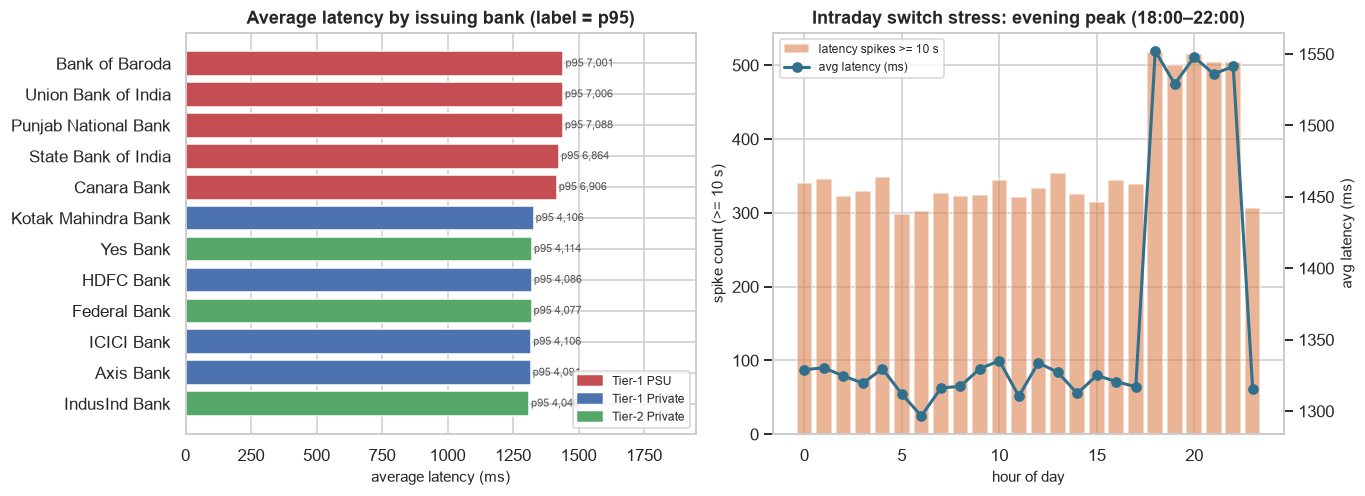

PSU banks run ~+8% avg latency vs Tier-1 private (1433 vs 1322 ms) and a spike share of 1.92% vs 1.47%. Worst three banks: Bank of Baroda, Union Bank of India, Punjab National Bank.
Evening 18-22h: avg latency 1541 ms vs 1321 ms off-peak (+17%); spikes average 508/hr vs 329/hr off-peak — an intraday capacity ceiling, not a success-rate dip (SR moves < 1 pp across hours).


In [14]:
hourly = (df_txns_banks.groupby("hour")
          .agg(txns=("txn_id", "size"), sr_pct=("status", success_rate),
               avg_latency_ms=("latency_ms", "mean"), spikes=("is_spike", "sum"))
          .reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

bp = bank_profile.sort_values("avg_latency_ms")
colors = bp["tier"].map({"TIER_1_PSU": "#c44e52", "TIER_1_PVT": "#4c72b0", "TIER_2_PVT": "#55a868"})
ax1.barh(bp["bank_name"], bp["avg_latency_ms"], color=colors)
for y, (lat, p95) in enumerate(zip(bp["avg_latency_ms"], bp["p95_latency_ms"])):
    ax1.text(lat + 8, y, f"p95 {p95:,.0f}", va="center", fontsize=7.5, color="#555")
ax1.set_xlim(0, bp["avg_latency_ms"].max() * 1.35)
ax1.set_xlabel("average latency (ms)")
ax1.set_title("Average latency by issuing bank (label = p95)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#c44e52", "#4c72b0", "#55a868"]]
ax1.legend(handles, ["Tier-1 PSU", "Tier-1 Private", "Tier-2 Private"], fontsize=8, loc="lower right")

ax2b = ax2.twinx()
ax2.bar(hourly["hour"], hourly["spikes"], color="#dd8452", alpha=0.6, label="latency spikes >= 10 s")
ax2.set_xlabel("hour of day"); ax2.set_ylabel("spike count (>= 10 s)")
ax2b.plot(hourly["hour"], hourly["avg_latency_ms"], color="#30708c", marker="o", lw=2,
          label="avg latency (ms)")
ax2b.set_ylabel("avg latency (ms)"); ax2b.grid(False)
ax2.set_title("Intraday switch stress: evening peak (18:00–22:00)")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

plt.tight_layout(); plt.show()

psu = tier_cmp.loc[tier_cmp["tier"] == "TIER_1_PSU"].iloc[0]
pvt = tier_cmp.loc[tier_cmp["tier"] == "TIER_1_PVT"].iloc[0]
evening = hourly[hourly["hour"].between(18, 22)]
offpeak = hourly[~hourly["hour"].between(18, 22)]
print(f"PSU banks run ~{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:+.0%} avg latency vs Tier-1 private "
      f"({psu['avg_latency_ms']:.0f} vs {pvt['avg_latency_ms']:.0f} ms) and a spike share of "
      f"{psu['spike_pct']:.2f}% vs {pvt['spike_pct']:.2f}%. Worst three banks: "
      f"{', '.join(bank_profile.head(3)['bank_name'])}.")
print(f"Evening 18-22h: avg latency {evening['avg_latency_ms'].mean():.0f} ms vs {offpeak['avg_latency_ms'].mean():.0f} ms off-peak "
      f"({evening['avg_latency_ms'].mean() / offpeak['avg_latency_ms'].mean() - 1:+.0%}); "
      f"spikes average {evening['spikes'].mean():,.0f}/hr vs {offpeak['spikes'].mean():,.0f}/hr off-peak — "
      f"an intraday capacity ceiling, not a success-rate dip (SR moves < 1 pp across hours).")

## 8 · Part 1 — KBQ 2: Error-Code Pareto — Infrastructure vs User-Side
Of every failed attempt, *who* is to blame? Upstream banking infrastructure
(`ERR_BANK_TIMEOUT`, `ERR_SWITCH_UNAVAILABLE`, `ERR_NPCI_DEGRADED`) vs user-side issues
(`ERR_INSUFFICIENT_FUNDS`, `ERR_AUTH_FAILED`). Note the accounting rule kept throughout:
`status = 'TIMEOUT'` rows and `error_code = 'ERR_BANK_TIMEOUT'` rows are **different counts** —
the Pareto works on error codes of all non-SUCCESS attempts.

In [15]:
df_failures = df_txns[df_txns["status"] != "SUCCESS"].copy()
total_failures = len(df_failures)

INFRA_CODES = ["ERR_BANK_TIMEOUT", "ERR_SWITCH_UNAVAILABLE", "ERR_NPCI_DEGRADED"]
pareto = df_failures["error_code"].value_counts().rename_axis("error_code").reset_index(name="failures")
pareto["fault_domain"] = np.where(pareto["error_code"].isin(INFRA_CODES), "Infrastructure", "User-side")
pareto["share_pct"] = pareto["failures"] / total_failures * 100
pareto["cumulative_pct"] = pareto["share_pct"].cumsum()
display(pareto)

infra_share = pareto.loc[pareto["fault_domain"] == "Infrastructure", "failures"].sum() / total_failures * 100

# USER_DROPPED <-> ERR_AUTH_FAILED pairing + the TIMEOUT accounting note
pairing = (df_failures.groupby(["status", "error_code"]).size()
           .reset_index(name="n").sort_values("n", ascending=False))
display(pairing)
timeout_status = int(df_txns["status"].eq("TIMEOUT").sum())
bank_timeout_on_failed = int((df_failures["status"].eq("FAILED")
                              & df_failures["error_code"].eq("ERR_BANK_TIMEOUT")).sum())

,error_code,failures,fault_domain,share_pct,cumulative_pct
0,ERR_BANK_TIMEOUT,39178,Infrastructure,45.325497,45.325497
1,ERR_AUTH_FAILED,28445,User-side,32.908361,78.233858
2,ERR_INSUFFICIENT_FUNDS,15785,User-side,18.261855,96.495714
3,ERR_NPCI_DEGRADED,1516,Infrastructure,1.753879,98.249592
4,ERR_SWITCH_UNAVAILABLE,1513,Infrastructure,1.750408,100.000000


,status,error_code,n
5,TIMEOUT,ERR_BANK_TIMEOUT,21611
1,FAILED,ERR_BANK_TIMEOUT,17567
2,FAILED,ERR_INSUFFICIENT_FUNDS,15785
0,FAILED,ERR_AUTH_FAILED,15646
6,USER_DROPPED,ERR_AUTH_FAILED,12799
3,FAILED,ERR_NPCI_DEGRADED,1516
4,FAILED,ERR_SWITCH_UNAVAILABLE,1513


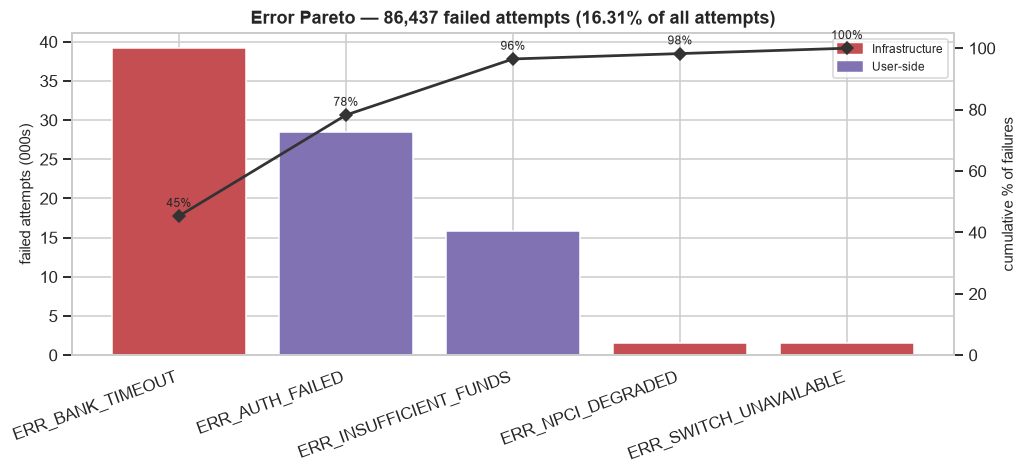

Failed attempts: 86,437 (16.31% of 530,000). Upstream infrastructure = 48.83% of failures, led by ERR_BANK_TIMEOUT (45.3%); user-side = 51.17%. Every USER_DROPPED attempt (12,799) carries ERR_AUTH_FAILED 1:1 — an authentication experience failure, not a switch fault; the same code also marks 15,646 FAILED attempts.
Accounting note: status='TIMEOUT' rows = 21,611 vs ERR_BANK_TIMEOUT on FAILED rows = 17,567 - the two counts overlap only conceptually and are never summed.


In [16]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(pareto))
colors = ["#c44e52" if d == "Infrastructure" else "#8172b3" for d in pareto["fault_domain"]]
ax.bar(x, pareto["failures"] / 1e3, color=colors)
ax.set_xticks(x); ax.set_xticklabels(pareto["error_code"], rotation=20, ha="right")
ax.set_ylabel("failed attempts (000s)")
axb = ax.twinx()
axb.plot(x, pareto["cumulative_pct"], color="#333", marker="D", lw=1.8)
axb.set_ylim(0, 105); axb.set_ylabel("cumulative % of failures"); axb.grid(False)
for xi, ci in zip(x, pareto["cumulative_pct"]):
    axb.annotate(f"{ci:.0f}%", (xi, ci), xytext=(0, 6), textcoords="offset points",
                 ha="center", fontsize=8)
ax.set_title(f"Error Pareto — {total_failures:,} failed attempts "
             f"({total_failures / kpi['total_txns'] * 100:.2f}% of all attempts)")
handles = [plt.Rectangle((0, 0), 1, 1, color="#c44e52"), plt.Rectangle((0, 0), 1, 1, color="#8172b3")]
ax.legend(handles, ["Infrastructure", "User-side"], fontsize=8)

plt.tight_layout(); plt.show()

auth_failed_rows = int(pairing.loc[(pairing["status"] == "USER_DROPPED")
                                   & (pairing["error_code"] == "ERR_AUTH_FAILED"), "n"].iloc[0])
auth_failed_on_failed = int(pairing.loc[(pairing["status"] == "FAILED")
                                        & (pairing["error_code"] == "ERR_AUTH_FAILED"), "n"].iloc[0])
print(f"Failed attempts: {total_failures:,} ({total_failures / kpi['total_txns']:.2%} of "
      f"{kpi['total_txns']:,}). Upstream infrastructure = {infra_share:.2f}% of failures, led by "
      f"ERR_BANK_TIMEOUT ({pareto.loc[pareto['error_code'] == 'ERR_BANK_TIMEOUT', 'share_pct'].iloc[0]:.1f}%); "
      f"user-side = {100 - infra_share:.2f}%. Every USER_DROPPED attempt ({auth_failed_rows:,}) carries "
      f"ERR_AUTH_FAILED 1:1 — an authentication experience failure, not a switch fault; the same code also "
      f"marks {auth_failed_on_failed:,} FAILED attempts.")
print(f"Accounting note: status='TIMEOUT' rows = {timeout_status:,} vs "
      f"ERR_BANK_TIMEOUT on FAILED rows = {bank_timeout_on_failed:,} - "
      f"the two counts overlap only conceptually and are never summed.")

## 9 · Part 2 — KBQ 3: Settlement Delay Diagnostics by Contracted SLA Cycle
Merchants contract payouts T+0 … T+3. We measure the SLA breach rate and delay severity per cycle,
the delay-day distribution, the monthly breach trend (stability check that later justifies
run-rate annualization), and an **MCC × cycle breach matrix** (multivariate diagnostic #1) rendered
as a seaborn heatmap.

In [17]:
# --- settlements enriched with merchant contract attributes ---
df_settlements_merchants = df_settlements.merge(
    df_merchants[["merchant_id", "merchant_tier", "settlement_cycle_sla", "mcc_category"]],
    on="merchant_id")

cycle = (df_settlements_merchants.groupby("settlement_cycle_sla")
         .agg(batches=("settlement_id", "size"), breach_pct=("sla_breach_flag", "mean"),
              avg_delay_days=("settlement_delay_days", "mean"))
         .reset_index())
cycle["breach_pct"] = cycle["breach_pct"] * 100
breached = df_settlements_merchants[df_settlements_merchants["sla_breach_flag"] == 1]
cycle = cycle.merge(breached.groupby("settlement_cycle_sla")["settlement_delay_days"].mean()
                    .rename("avg_delay_if_breach_days").reset_index(), on="settlement_cycle_sla")
cycle = cycle.rename(columns={"settlement_cycle_sla": "sla_cycle"}).sort_values("sla_cycle")
display(cycle)

delay_dist = (df_settlements["settlement_delay_days"].value_counts()
              .sort_index().rename_axis("delay_days").reset_index(name="batches"))
display(delay_dist)

monthly_breach = (df_settlements[df_settlements["batch_month"] <= "2024-12"]
                  .groupby("batch_month")
                  .agg(batches=("settlement_id", "size"), breach_pct=("sla_breach_flag", "mean"))
                  .reset_index())
monthly_breach["breach_pct"] = monthly_breach["breach_pct"] * 100
print(f"Monthly breach-rate range (2023-07..2024-12): "
      f"{monthly_breach['breach_pct'].min():.1f}% – {monthly_breach['breach_pct'].max():.1f}%  → flat, no seasonality.")

,sla_cycle,batches,breach_pct,avg_delay_days,avg_delay_if_breach_days
0,T_PLUS_0,4311,12.224542,0.138947,1.136622
1,T_PLUS_1,66643,11.962247,0.139790,1.168590
2,T_PLUS_2,42227,49.555971,0.854714,1.724744
3,T_PLUS_3,11819,51.738726,0.931805,1.800981


,delay_days,batches
0,0,89460
1,1,20062
2,2,10419
3,3,4116
4,4,943


Monthly breach-rate range (2023-07..2024-12): 27.7% – 29.5%  → flat, no seasonality.


settlement_cycle_sla,T_PLUS_0,T_PLUS_1,T_PLUS_2,T_PLUS_3
mcc_category,,,,
EDTECH,10.416667,11.722659,47.113503,43.726937
E_COMMERCE,12.464387,12.157674,49.571013,53.299941
FOOD_DINING,13.547646,11.840275,49.240122,52.967564
GAMING_ENTERTAINMENT,11.576355,11.961302,49.500000,53.056769
HEALTHCARE_RETAIL,11.940299,12.203448,47.815750,45.986985
TRAVEL_HOSPITALITY,14.285714,11.906039,49.914302,48.484848
UTILITIES_BILLS,9.285714,11.761805,51.692362,54.277286


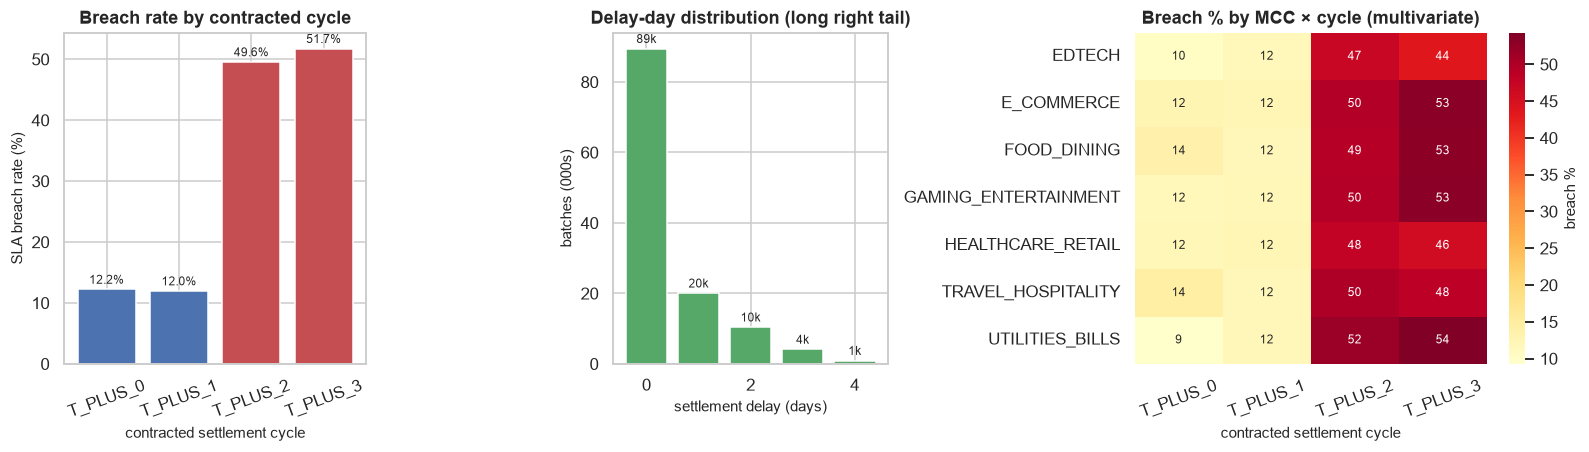

T+0/T+1 contracts breach at ~12.2% while T+2/T+3 contracts breach at ~50% — a 4x structural gap. Breached batches still arrive ~1.5 days late on average, and the MCC × cycle matrix shows the T+2/T+3 breach failure is platform-wide (every MCC), not a category quirk.


In [18]:
mcc_matrix = (df_settlements_merchants
             .pivot_table(index="mcc_category", columns="settlement_cycle_sla",
                          values="sla_breach_flag", aggfunc="mean") * 100)
mcc_matrix = mcc_matrix.reindex(columns=["T_PLUS_0", "T_PLUS_1", "T_PLUS_2", "T_PLUS_3"])
display(mcc_matrix)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                         gridspec_kw={"width_ratios": [1.1, 1.0, 1.6]})

ax = axes[0]
ax.bar(cycle["sla_cycle"], cycle["breach_pct"],
       color=["#4c72b0", "#4c72b0", "#c44e52", "#c44e52"])
label_bars(ax, "{:,.1f}%")
ax.set_ylabel("SLA breach rate (%)"); ax.set_xlabel("contracted settlement cycle")
ax.set_title("Breach rate by contracted cycle")
ax.tick_params(axis="x", rotation=20)

ax = axes[1]
ax.bar(delay_dist["delay_days"], delay_dist["batches"] / 1e3, color="#55a868")
label_bars(ax, "{:,.0f}k")
ax.set_xlabel("settlement delay (days)"); ax.set_ylabel("batches (000s)")
ax.set_title("Delay-day distribution (long right tail)")

ax = axes[2]
sns.heatmap(mcc_matrix, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "breach %"}, annot_kws={"fontsize": 8})
ax.set_xlabel("contracted settlement cycle"); ax.set_ylabel("")
ax.set_title("Breach % by MCC × cycle (multivariate)")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

t0 = cycle.loc[cycle["sla_cycle"] == "T_PLUS_0", "breach_pct"].iloc[0]
t2 = cycle.loc[cycle["sla_cycle"] == "T_PLUS_2", "breach_pct"].iloc[0]
print(f"T+0/T+1 contracts breach at ~{t0:.1f}% while T+2/T+3 contracts breach at ~{t2:.0f}% — a 4x structural gap. "
      f"Breached batches still arrive ~{cycle['avg_delay_if_breach_days'].mean():.1f} days late on average, "
      f"and the MCC × cycle matrix shows the T+2/T+3 breach failure is platform-wide (every MCC), not a category quirk.")

## 10 · Part 2 — KBQ 4: Settlement Friction vs Merchant Attrition (Multivariate Diagnostic #2)
Does *recurrent* settlement breach actually precede churn? We segment merchants by **SLA-breach
exposure bucket** × **tier**, compare churn rates within the covered population (coverage shown not
to bias churn in the quality block), and decompose churn reasons.

In [19]:
churn_tier = (df_merchants.groupby("merchant_tier")
             .agg(merchants=("merchant_id", "size"), churned=("is_churned", "sum"),
                  churn_pct=("is_churned", "mean"))
             .reset_index())
churn_tier["churn_pct"] = churn_tier["churn_pct"] * 100
churn_tier = churn_tier.set_index("merchant_tier").reindex(TIER_ORDER).reset_index()
display(churn_tier)

churn_matrix = (df_merchant_exposure.groupby(["merchant_tier", "breach_bucket"])
                .agg(merchants=("merchant_id", "size"), churned=("is_churned", "sum"),
                     churn_pct=("is_churned", "mean"))
                .reset_index())
churn_matrix["churn_pct"] = churn_matrix["churn_pct"] * 100
churn_pivot = (churn_matrix.pivot(index="merchant_tier", columns="breach_bucket", values="churn_pct")
               .reindex(TIER_ORDER)[BUCKET_ORDER])
churn_n = (churn_matrix.pivot(index="merchant_tier", columns="breach_bucket", values="merchants")
           .reindex(TIER_ORDER)[BUCKET_ORDER])
display(churn_pivot)
display(churn_n)

smb = churn_pivot.loc["SMB"]
smb_ratio = smb[">25%"] / smb["0-10%"]
mm = churn_pivot.loc["MID_MARKET"]
print(f"SMB churn: >25%-breach bucket {smb['>25%']:.2f}% vs low-breach 0-10% bucket {smb['0-10%']:.2f}% "
      f"→ {smb_ratio:.1f}x more likely to churn under recurrent breaches. "
      f"MID_MARKET shows the same direction ({mm['>25%']:.2f}% vs {mm['0-10%']:.2f}%), ENTERPRISE barely moves — "
      f"small merchants absorb the working-capital shock.")

,merchant_tier,merchants,churned,churn_pct
0,ENTERPRISE,696,22,3.160920
1,MID_MARKET,2349,174,7.407407
2,SMB,5455,1182,21.668194


breach_bucket,0%,0-10%,10-25%,>25%
merchant_tier,,,,
ENTERPRISE,0.0,1.333333,2.500000,NaN
MID_MARKET,0.0,4.137931,1.515152,14.427861
SMB,0.0,10.116732,8.757637,32.662192


breach_bucket,0%,0-10%,10-25%,>25%
merchant_tier,,,,
ENTERPRISE,2.0,75.0,120.0,NaN
MID_MARKET,1.0,145.0,330.0,201.0
SMB,1.0,257.0,491.0,894.0


SMB churn: >25%-breach bucket 32.66% vs low-breach 0-10% bucket 10.12% → 3.2x more likely to churn under recurrent breaches. MID_MARKET shows the same direction (14.43% vs 4.14%), ENTERPRISE barely moves — small merchants absorb the working-capital shock.


merchant_tier,ENTERPRISE,MID_MARKET,SMB
churn_reason,,,
COMPETITOR_SWITCH,6,33,227
HIGH_FAILURE_RATE,4,40,281
HIGH_MDR_FEES,12,24,93
SETTLEMENT_DELAY,0,77,581


,merchant_tier,avg_tenure_days,churned
0,ENTERPRISE,144.363636,22
1,MID_MARKET,147.649425,174
2,SMB,148.431472,1182


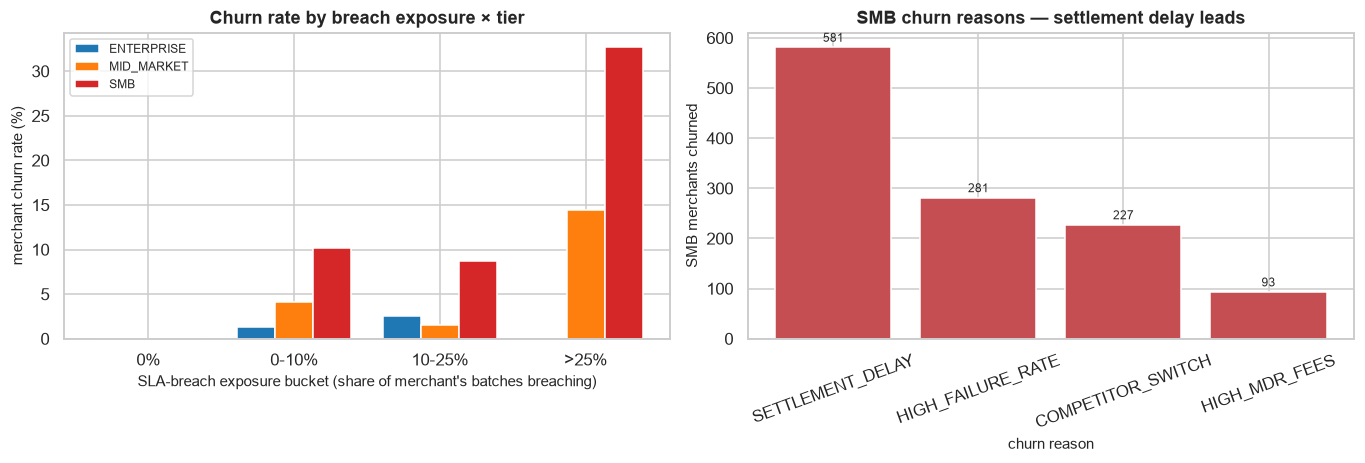

581 of 1182 SMB churners (49%) cite SETTLEMENT_DELAY as the reason — the exposure gradient above is the mechanism, and churned merchants leave after ~147 days on platform regardless of tier.


In [20]:
df_churned = df_merchants[df_merchants["is_churned"]].copy()
reasons = (df_churned.groupby(["merchant_tier", "churn_reason"]).size()
           .reset_index(name="merchants"))
reasons_pivot = (reasons.pivot(index="churn_reason", columns="merchant_tier", values="merchants")
                 .fillna(0).astype(int))
display(reasons_pivot)

reasons_smb = reasons[reasons["merchant_tier"] == "SMB"].sort_values("merchants", ascending=False)

df_churned["tenure_days"] = (df_churned["churn_date"] - df_churned["onboarding_date"]).dt.days
tenure = df_churned.groupby("merchant_tier")["tenure_days"].agg(["mean", "size"]).reset_index()
tenure.columns = ["merchant_tier", "avg_tenure_days", "churned"]
display(tenure)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

x = np.arange(len(BUCKET_ORDER)); w = 0.26
for i, tier in enumerate(TIER_ORDER):
    ax1.bar(x + (i - 1) * w, churn_pivot.loc[tier], width=w, label=tier, color=TIER_COLORS[tier])
ax1.set_xticks(x); ax1.set_xticklabels(BUCKET_ORDER)
ax1.set_xlabel("SLA-breach exposure bucket (share of merchant's batches breaching)")
ax1.set_ylabel("merchant churn rate (%)")
ax1.set_title("Churn rate by breach exposure × tier")
ax1.legend(fontsize=8)

ax2.bar(reasons_smb["churn_reason"], reasons_smb["merchants"], color="#c44e52")
label_bars(ax2)
ax2.set_xlabel("churn reason"); ax2.set_ylabel("SMB merchants churned")
ax2.set_title("SMB churn reasons — settlement delay leads")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

smb_delay_churn = int(reasons_smb.loc[reasons_smb["churn_reason"] == "SETTLEMENT_DELAY", "merchants"].iloc[0])
smb_churn_total = int(churn_tier.loc[churn_tier["merchant_tier"] == "SMB", "churned"].iloc[0])
print(f"{smb_delay_churn} of {smb_churn_total} SMB churners ({smb_delay_churn / smb_churn_total * 100:.0f}%) cite "
      f"SETTLEMENT_DELAY as the reason — the exposure gradient above is the mechanism, and churned merchants "
      f"leave after ~{tenure['avg_tenure_days'].mean():.0f} days on platform regardless of tier.")

## 11 · Part 3 — KBQ 5 & 6: Dynamic SLA Smart-Routing — A/B Lift & Latency Mitigation
**Benchmark to verify: +8.50 pp absolute success-rate lift (accepted band 8.30–8.70 pp),
baseline ~79.5% → ~88.0%.** We compute the A/B comparison, test lift stability across tiers and
channels (multivariate diagnostic #3), then quantify the latency reduction from bypassing degraded
switches (multivariate diagnostic #4: route × bank). Quantiles here are plain
`groupby(...)['latency_ms'].quantile()` calls — pandas needs no window-function tricks.

In [21]:
ab = (df_txns.groupby("is_routed_via_dynamic_sla")
      .agg(txns=("txn_id", "size"), sr_pct=("status", success_rate),
           avg_latency_ms=("latency_ms", "mean"))
      .reset_index())
display(ab)

sr_standard = ab.loc[ab["is_routed_via_dynamic_sla"] == 0, "sr_pct"].iloc[0]
sr_dynamic = ab.loc[ab["is_routed_via_dynamic_sla"] == 1, "sr_pct"].iloc[0]
lift = sr_dynamic - sr_standard

# --- lift stability across segments (multivariate diagnostic #3) ---
df_txns_tiers = df_txns.merge(df_merchants[["merchant_id", "merchant_tier"]], on="merchant_id")
lift_tier = (df_txns_tiers.groupby(["merchant_tier", "is_routed_via_dynamic_sla"])
             ["status"].agg(success_rate).unstack())
lift_tier.columns = [0, 1]
lift_tier["lift_pp"] = lift_tier[1] - lift_tier[0]
lift_tier = lift_tier.reindex(TIER_ORDER)

df_txns_channels = df_txns.merge(df_methods[["payment_method_id", "payment_channel"]], on="payment_method_id")
lift_channel = (df_txns_channels.groupby(["payment_channel", "is_routed_via_dynamic_sla"])
                ["status"].agg(success_rate).unstack())
lift_channel.columns = [0, 1]
lift_channel["lift_pp"] = lift_channel[1] - lift_channel[0]

display(lift_tier)
display(lift_channel)

print(f"SUCCESS-RATE LIFT: standard {sr_standard:.2f}% -> dynamic {sr_dynamic:.2f}% = +{lift:.2f} pp")
print(f"Benchmark check: target +8.50 pp, accepted band 8.30-8.70 pp -> "
      f"{'PASS' if 8.30 <= lift <= 8.70 else 'FAIL'}")
assert 8.30 <= lift <= 8.70, f"Routing lift {lift:.2f} pp outside accepted band 8.30-8.70 pp!"
print(f"Lift is stable across tiers (range {lift_tier['lift_pp'].min():.2f}-{lift_tier['lift_pp'].max():.2f} pp) "
      f"and channels (range {lift_channel['lift_pp'].min():.2f}-{lift_channel['lift_pp'].max():.2f} pp) — "
      f"a platform-wide engine effect, not a segment artifact.")

,is_routed_via_dynamic_sla,txns,sr_pct,avg_latency_ms
0,0,264736,79.403255,1700.050975
1,1,265264,87.970475,1034.859276


,0,1,lift_pp
merchant_tier,,,
ENTERPRISE,79.677508,87.885096,8.207588
MID_MARKET,79.521951,87.795179,8.273228
SMB,79.316882,88.056550,8.739667


,0,1,lift_pp
payment_channel,,,
CREDIT_CARD,79.415485,87.988433,8.572948
DEBIT_CARD,79.589519,87.631826,8.042307
NET_BANKING,79.296541,88.038200,8.741659
UPI,79.372354,88.004639,8.632284
WALLET,79.304447,88.488317,9.183870


SUCCESS-RATE LIFT: standard 79.40% -> dynamic 87.97% = +8.57 pp
Benchmark check: target +8.50 pp, accepted band 8.30-8.70 pp -> PASS
Lift is stable across tiers (range 8.21-8.74 pp) and channels (range 8.04-9.18 pp) — a platform-wide engine effect, not a segment artifact.


,avg_latency_ms,p50_ms,p95_ms
is_routed_via_dynamic_sla,,,
0,1700.050975,1054.0,7335.25
1,1034.859276,570.0,3793.00


,0,1,improvement_ms
bank_name,,,
Bank of Baroda,1793.692388,1096.415131,697.277258
Canara Bank,1792.060634,1043.426479,748.634154
Union Bank of India,1784.455938,1101.021544,683.434394
State Bank of India,1780.716669,1072.405852,708.310817
Punjab National Bank,1778.917430,1104.508619,674.408811
Kotak Mahindra Bank,1655.507241,999.930485,655.576756


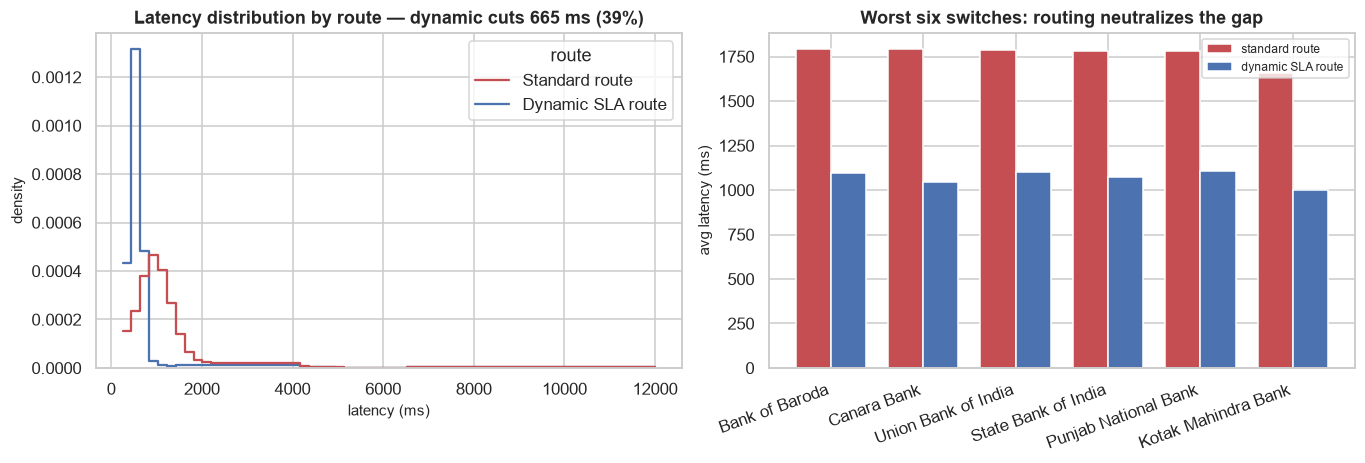

Dynamic routing cuts average latency 1,700 -> 1,035 ms (-665 ms, 39%) and p95 7,335 -> 3,793 ms. On every degraded PSU switch the dynamic route claws back 666 ms on average.


In [22]:
# --- latency percentiles by route (pandas quantile) ---
latency_q = df_txns.groupby("is_routed_via_dynamic_sla")["latency_ms"].quantile([0.50, 0.95]).unstack()
latency_route = ab[["is_routed_via_dynamic_sla", "avg_latency_ms"]].merge(
    latency_q.reset_index().rename(columns={0.50: "p50_ms", 0.95: "p95_ms"}),
    on="is_routed_via_dynamic_sla")
latency_route = latency_route.set_index("is_routed_via_dynamic_sla")
display(latency_route)

lat_reduction = latency_route.loc[0, "avg_latency_ms"] - latency_route.loc[1, "avg_latency_ms"]

# --- route x bank (multivariate diagnostic #4) ---
route_bank = (df_txns_banks.groupby(["bank_name", "is_routed_via_dynamic_sla"])["latency_ms"]
              .mean().unstack())
route_bank.columns = [0, 1]
route_bank["improvement_ms"] = route_bank[0] - route_bank[1]
route_bank = route_bank.sort_values(0, ascending=False)
display(route_bank.head(6))

# --- labelled latency sample for the histogram ---
df_route_latency = df_txns[["latency_ms", "is_routed_via_dynamic_sla"]].copy()
df_route_latency["route"] = df_route_latency["is_routed_via_dynamic_sla"].map(
    {0: "Standard route", 1: "Dynamic SLA route"})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

sns.histplot(data=df_route_latency, x="latency_ms", hue="route", bins=60, stat="density",
             element="step", fill=False, palette=["#c44e52", "#4c72b0"], ax=ax1)
ax1.set_xlabel("latency (ms)"); ax1.set_ylabel("density")
ax1.set_title(f"Latency distribution by route — dynamic cuts {lat_reduction:,.0f} ms "
              f"({lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%)")

top6 = route_bank.head(6)
x = np.arange(len(top6)); w = 0.38
ax2.bar(x - w / 2, top6[0], width=w, label="standard route", color="#c44e52")
ax2.bar(x + w / 2, top6[1], width=w, label="dynamic SLA route", color="#4c72b0")
ax2.set_xticks(x); ax2.set_xticklabels(top6.index, rotation=20, ha="right")
ax2.set_ylabel("avg latency (ms)")
ax2.set_title("Worst six switches: routing neutralizes the gap")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Dynamic routing cuts average latency {latency_route.loc[0, 'avg_latency_ms']:,.0f} -> "
      f"{latency_route.loc[1, 'avg_latency_ms']:,.0f} ms (-{lat_reduction:,.0f} ms, "
      f"{lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%) and p95 "
      f"{latency_route.loc[0, 'p95_ms']:,.0f} -> {latency_route.loc[1, 'p95_ms']:,.0f} ms. "
      f"On every degraded PSU switch the dynamic route claws back "
      f"{route_bank['improvement_ms'].mean():,.0f} ms on average.")

## 12 · Part 4 — KBQ 7: MDR Revenue Economics by Tier × Channel
Two accounting lenses, kept distinct: **realized** MDR = fee actually deducted on settled batches
(`net_mdr_deducted_inr` in `df_settlements`); **potential** MDR = successful transaction volume ×
contracted `mdr_rate_pct` (via the `df_txns_methods` join). UPI's 0% MDR makes volume and revenue
diverge sharply.

In [23]:
# --- realized: settlements joined to merchant tiers ---
realized_tier = (df_settlements.merge(df_merchants[["merchant_id", "merchant_tier"]], on="merchant_id")
                 .groupby("merchant_tier")
                 .agg(batches=("settlement_id", "size"),
                      gpv_m=("gross_volume_inr", lambda s: s.sum() / 1e6),
                      mdr_m=("net_mdr_deducted_inr", lambda s: s.sum() / 1e6))
                 .reset_index())
realized_tier["blended_mdr_pct"] = 100 * (realized_tier["mdr_m"] * 1e6) / (realized_tier["gpv_m"] * 1e6)
realized_tier = realized_tier.set_index("merchant_tier").reindex(TIER_ORDER).reset_index()
display(realized_tier)

# --- potential: successful volume x contracted rate (per channel) ---
potential_channel = (df_success.groupby("payment_channel")
                     .agg(gmv_success_m=("amount_inr", lambda s: s.sum() / 1e6),
                          mdr_potential_m=("mdr_amount_inr", lambda s: s.sum() / 1e6))
                     .reset_index())
rates = df_methods.groupby("payment_channel")["mdr_rate_pct"].agg(["min", "max"]).reset_index()
potential_channel = potential_channel.merge(rates, on="payment_channel")
total_success_gmv = df_success["amount_inr"].sum()
potential_channel["gmv_share_pct"] = potential_channel["gmv_success_m"] * 1e6 / total_success_gmv * 100
potential_channel = potential_channel.sort_values("mdr_potential_m", ascending=False)
display(potential_channel)

# --- tier x channel potential (multivariate revenue view) ---
df_success_tiers = df_success.merge(df_merchants[["merchant_id", "merchant_tier"]], on="merchant_id")
tier_channel = (df_success_tiers.pivot_table(index="merchant_tier", columns="payment_channel",
                                             values="mdr_amount_inr", aggfunc="sum") / 1e6)
tier_channel = tier_channel.reindex(TIER_ORDER)
display(tier_channel)

monthly_mdr = (df_settlements[df_settlements["settle_month"] <= "2024-12"]
               .groupby("settle_month")["net_mdr_deducted_inr"].sum() / 1e6)
monthly_mdr = monthly_mdr.rename("realized_mdr_m").reset_index()

,merchant_tier,batches,gpv_m,mdr_m,blended_mdr_pct
0,ENTERPRISE,9801,17.070373,0.222569,1.303831
1,MID_MARKET,33606,58.379626,0.761341,1.304121
2,SMB,81593,142.274019,1.847265,1.298385


,payment_channel,gmv_success_m,mdr_potential_m,min,max,gmv_share_pct
0,CREDIT_CARD,147.034944,2.530281,1.2,2.40,20.134958
1,DEBIT_CARD,102.598128,0.850925,0.4,0.90,14.049783
2,NET_BANKING,51.150579,0.778371,1.5,1.65,7.004558
4,WALLET,28.703675,0.322833,1.1,1.15,3.930680
3,UPI,400.759762,0.000000,0.0,0.00,54.880022


payment_channel,CREDIT_CARD,DEBIT_CARD,NET_BANKING,UPI,WALLET
merchant_tier,,,,,
ENTERPRISE,0.206466,0.071598,0.065839,0.0,0.028408
MID_MARKET,0.695177,0.234798,0.213871,0.0,0.088562
SMB,1.628638,0.544530,0.498662,0.0,0.205863


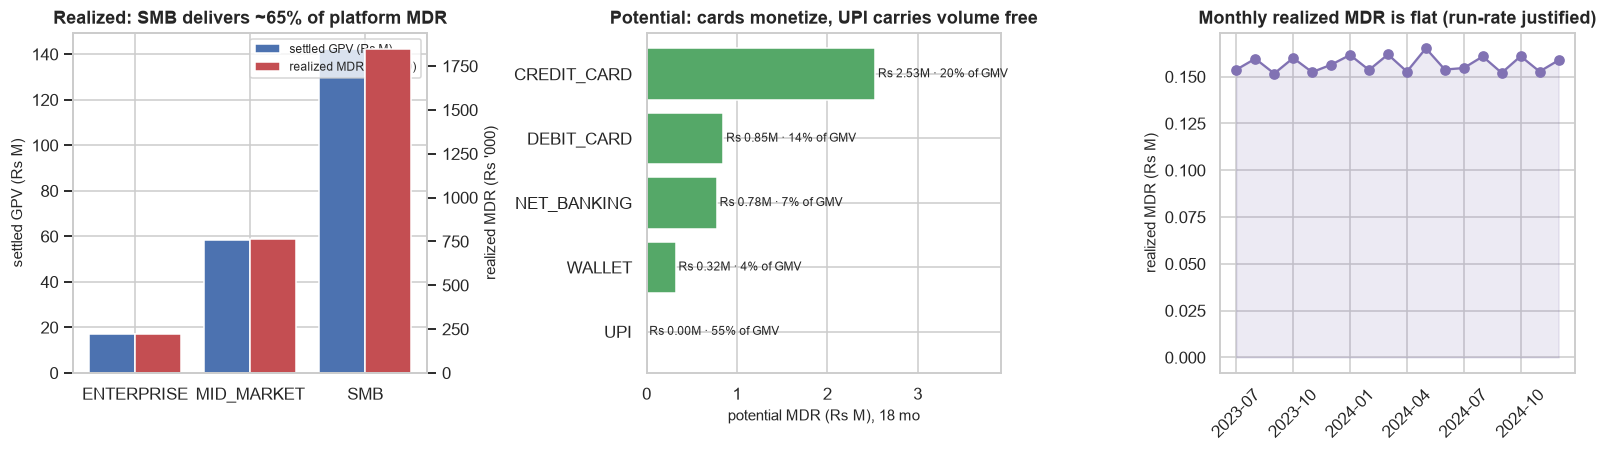

Realized MDR (18 mo): Rs 2.831M on settled GPV of Rs 217.72M (blended 1.30%). SMB contributes 65% of platform MDR — losing SMB merchants to settlement failures is a direct revenue event.
Channel mix: UPI = 55% of successful GMV at 0% MDR; credit cards generate 56% of potential MDR from ~20% of GMV (rates 1.2-2.4%) — monetization is card-concentrated.


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

ax = axes[0]
x = np.arange(len(realized_tier))
ax.bar(x - 0.2, realized_tier["gpv_m"], width=0.4, label="settled GPV (Rs M)", color="#4c72b0")
axb = ax.twinx()
axb.bar(x + 0.2, realized_tier["mdr_m"] * 1000, width=0.4, label="realized MDR (Rs '000)", color="#c44e52")
axb.grid(False)
ax.set_xticks(x); ax.set_xticklabels(realized_tier["merchant_tier"])
ax.set_ylabel("settled GPV (Rs M)"); axb.set_ylabel("realized MDR (Rs '000)")
ax.set_title("Realized: SMB delivers ~65% of platform MDR")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

ax = axes[1]
pc = potential_channel.sort_values("mdr_potential_m")
ax.barh(pc["payment_channel"], pc["mdr_potential_m"], color="#55a868")
for y, (m, share) in enumerate(zip(pc["mdr_potential_m"], pc["gmv_share_pct"])):
    ax.text(m + 0.03, y, f"Rs {m:,.2f}M · {share:.0f}% of GMV", va="center", fontsize=8)
ax.set_xlim(0, pc["mdr_potential_m"].max() * 1.55)
ax.set_xlabel("potential MDR (Rs M), 18 mo")
ax.set_title("Potential: cards monetize, UPI carries volume free")

ax = axes[2]
ax.plot(monthly_mdr["settle_month"], monthly_mdr["realized_mdr_m"], marker="o", color="#8172b3")
ax.fill_between(monthly_mdr["settle_month"], monthly_mdr["realized_mdr_m"], alpha=0.15, color="#8172b3")
ax.set_xticks(monthly_mdr["settle_month"][::3])
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("realized MDR (Rs M)")
ax.set_title("Monthly realized MDR is flat (run-rate justified)")

plt.tight_layout(); plt.show()

total_mdr = realized_tier["mdr_m"].sum()
smb_mdr_share = realized_tier.loc[realized_tier["merchant_tier"] == "SMB", "mdr_m"].iloc[0] / total_mdr * 100
upi_gmv_share = potential_channel.loc[potential_channel["payment_channel"] == "UPI", "gmv_share_pct"].iloc[0]
cc_mdr_share = (potential_channel.loc[potential_channel["payment_channel"] == "CREDIT_CARD", "mdr_potential_m"].iloc[0]
                / potential_channel["mdr_potential_m"].sum() * 100)
print(f"Realized MDR (18 mo): Rs {total_mdr:,.3f}M on settled GPV of Rs {realized_tier['gpv_m'].sum():,.2f}M "
      f"(blended {100 * total_mdr / realized_tier['gpv_m'].sum():.2f}%). "
      f"SMB contributes {smb_mdr_share:.0f}% of platform MDR — losing SMB merchants to settlement failures is a "
      f"direct revenue event.")
print(f"Channel mix: UPI = {upi_gmv_share:.0f}% of successful GMV at 0% MDR; credit cards generate "
      f"{cc_mdr_share:.0f}% of potential MDR from ~20% of GMV (rates 1.2-2.4%) — monetization is card-concentrated.")

## 13 · Part 4 — KBQ 8: Protected Volume — What Eliminating Settlement Delays Saves
Sizing the annualized GMV and MDR preserved by fixing settlement breaches for **at-risk SMB merchants**
(> 25% of their batches breaching). Two scenarios: the **at-stake ceiling** (the whole segment's run-rate)
and an **excess-churn scenario** (churn reverts from the high-breach rate to the low-breach SMB baseline).
All figures annualize the trailing 18-month run-rate × 12/18 — justified by the flat monthly breach
(≈ 28%) and MDR trend verified in Part 2 / KBQ 7.

,metric,value
0,at-risk SMB merchants (>25% batches breaching),894
1,observed churn in segment,32.66%
2,low-breach SMB baseline churn (0-10%),10.12%
3,excess churn pp,22.55 pp
4,saveable merchants (excess model),202
5,segment annualized GMV (at-stake ceiling),Rs 51.6M / yr
6,segment annualized realized MDR (ceiling),Rs 0.669M / yr
7,protected GMV (excess-churn scenario),Rs 11.6M / yr
8,protected MDR (excess-churn scenario),Rs 0.151M / yr


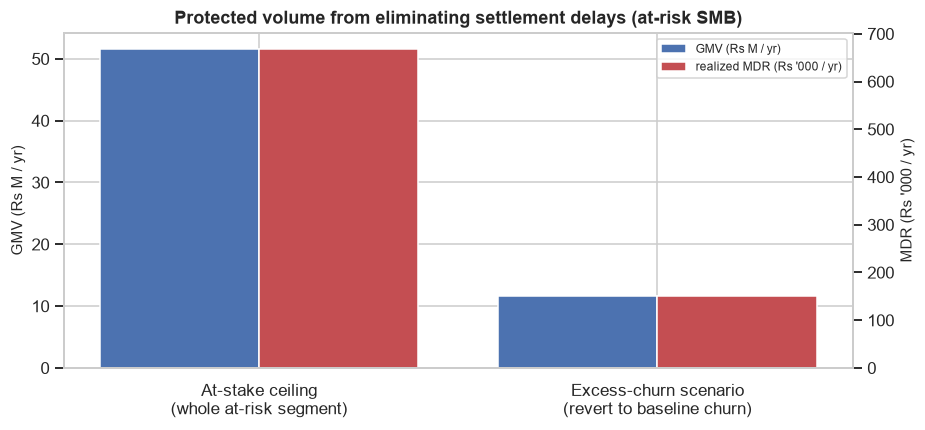

Assumptions: (1) trailing 18-month run-rate x 12/18 annualization — flat breach (~28%/mo) and MDR trend verified; (2) fixing breaches moves segment churn to the low-breach baseline (10.1%); (3) retained merchants sustain segment-average GPV/MDR economics; (4) no credit taken for replacement acquisition (conservative).


In [25]:
at_risk = df_merchant_exposure[(df_merchant_exposure["merchant_tier"] == "SMB")
                               & (df_merchant_exposure["breach_bucket"] == ">25%")]
n_risk = len(at_risk)
risk_churn_pct = at_risk["is_churned"].mean() * 100
risk_gpv_annual_m = at_risk["gpv_inr"].sum() / 1e6 * 12 / 18
risk_mdr_annual_m = at_risk["mdr_inr"].sum() / 1e6 * 12 / 18

smb_low = df_merchant_exposure[(df_merchant_exposure["merchant_tier"] == "SMB")
                               & (df_merchant_exposure["breach_bucket"] == "0-10%")]
baseline_churn_pct = smb_low["is_churned"].mean() * 100
excess_pp = risk_churn_pct - baseline_churn_pct
saveable = n_risk * excess_pp / 100
# merchants saveable = segment size x excess churn rate; protected volume = segment run-rate x same share
protected_share = excess_pp / 100
protected_gpv_annual_m = risk_gpv_annual_m * protected_share
protected_mdr_annual_m = risk_mdr_annual_m * protected_share

display(pd.DataFrame({
    "metric": ["at-risk SMB merchants (>25% batches breaching)", "observed churn in segment",
               "low-breach SMB baseline churn (0-10%)", "excess churn pp", "saveable merchants (excess model)",
               "segment annualized GMV (at-stake ceiling)", "segment annualized realized MDR (ceiling)",
               "protected GMV (excess-churn scenario)", "protected MDR (excess-churn scenario)"],
    "value": [f"{n_risk:,}", f"{risk_churn_pct:.2f}%", f"{baseline_churn_pct:.2f}%",
              f"{excess_pp:.2f} pp", f"{saveable:,.0f}",
              f"Rs {risk_gpv_annual_m:,.1f}M / yr", f"Rs {risk_mdr_annual_m:.3f}M / yr",
              f"Rs {protected_gpv_annual_m:,.1f}M / yr", f"Rs {protected_mdr_annual_m:.3f}M / yr"],
}))

fig, ax = plt.subplots(figsize=(8.5, 4))
scen = ["At-stake ceiling\n(whole at-risk segment)", "Excess-churn scenario\n(revert to baseline churn)"]
gpv_vals = [risk_gpv_annual_m, protected_gpv_annual_m]
mdr_vals = [risk_mdr_annual_m * 1000, protected_mdr_annual_m * 1000]
x = np.arange(2)
ax.bar(x - 0.2, gpv_vals, width=0.4, label="GMV (Rs M / yr)", color="#4c72b0")
axb = ax.twinx()
axb.bar(x + 0.2, mdr_vals, width=0.4, label="realized MDR (Rs '000 / yr)", color="#c44e52")
axb.grid(False)
ax.set_xticks(x); ax.set_xticklabels(scen)
ax.set_ylabel("GMV (Rs M / yr)"); axb.set_ylabel("MDR (Rs '000 / yr)")
ax.set_title("Protected volume from eliminating settlement delays (at-risk SMB)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

plt.tight_layout(); plt.show()

print(f"Assumptions: (1) trailing 18-month run-rate x 12/18 annualization — flat breach (~28%/mo) and MDR trend "
      f"verified; (2) fixing breaches moves segment churn to the low-breach baseline ({baseline_churn_pct:.1f}%); "
      f"(3) retained merchants sustain segment-average GPV/MDR economics; (4) no credit taken for replacement "
      f"acquisition (conservative).")

## 14 · Findings → 5 Prioritized Recommendations & Executive Summary
Each recommendation follows **Finding → Business Problem → Recommendation → Expected Impact**,
with impact quantified from this notebook's own outputs and assumptions stated inline.
★ = top-3 priority for the executive deck.

In [26]:
from IPython.display import Markdown

smb_merchants = int(churn_tier.loc[churn_tier["merchant_tier"] == "SMB", "merchants"].iloc[0])
avg_ticket = kpi["gmv_attempted_m"] * 1e6 / kpi["total_txns"]

exec_md = Markdown(f"""\
### Recommendations (prioritized)

**★ 1. Reroute settlement-bound payouts for breach-exposed SMB merchants (T+2/T+3 contracts)**
* **Finding:** T+2/T+3 cycles breach SLA ~{cycle.loc[cycle['sla_cycle'] == 'T_PLUS_2', 'breach_pct'].iloc[0]:.0f}–{cycle.loc[cycle['sla_cycle'] == 'T_PLUS_3', 'breach_pct'].iloc[0]:.0f}% vs ~{t0:.0f}% on T+0/T+1; SMB merchants in the >25%-breach bucket churn at {risk_churn_pct:.1f}% vs {baseline_churn_pct:.1f}% for low-breach peers ({smb_ratio:.1f}×).
* **Problem:** Recurrent payout delays create SMB working-capital stress; {smb_delay_churn} SMB churners ({smb_delay_churn / smb_churn_total * 100:.0f}% of SMB churn) cite settlement delay — and SMB pays {smb_mdr_share:.0f}% of platform MDR.
* **Recommendation:** Guarantee T+1 payouts for breach-exposed SMB via a liquidity buffer / early-settlement program; cap new SMB onboarding on T+2/T+3 contracts.
* **Expected impact:** Protects **Rs {protected_gpv_annual_m:,.0f}M GMV / Rs {protected_mdr_annual_m * 1000:,.0f}K MDR per year** (excess-churn scenario; assumptions in KBQ 8: run-rate annualization, churn reversion to {baseline_churn_pct:.1f}% baseline, no replacement credit). *Assumption:* net funding cost of the buffer < protected MDR.

**★ 2. Shift smart-routing to 100% of traffic and prioritize PSU bank de-congestion in the evening window**
* **Finding:** Dynamic SLA routing lifts success **+{lift:.2f} pp** ({sr_standard:.2f}% → {sr_dynamic:.2f}%, within the 8.30–8.70 band) and cuts latency {lat_reduction:,.0f} ms ({lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%); PSU switches run ~{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:+.0%} latency vs private and evening 18–22 h spike counts run ~{evening['spikes'].mean() / offpeak['spikes'].mean() - 1:+.0%}.
* **Problem:** {total_failures:,} failed attempts ({total_failures / kpi['total_txns'] * 100:.1f}% of volume), {infra_share:.0f}% infrastructure-attributable; every failed attempt risks drop-off on zero-fee UPI and MDR loss on cards.
* **Recommendation:** Default-route all traffic through the dynamic SLA engine; add explicit evening (18–22 h) capacity throttling toward private-switch rails for PSU-bound volume; publish a bank-switch SLA scorecard and renegotiate with the worst three ({', '.join(bank_profile.head(3)['bank_name'])}).
* **Expected impact:** Closing the remaining routed/unrouted gap on ~{int(ab.loc[ab['is_routed_via_dynamic_sla'] == 0, 'txns'].iloc[0]):,.0f} still-unrouted attempts is worth ≈ **{ab.loc[ab['is_routed_via_dynamic_sla'] == 0, 'txns'].iloc[0] * lift / 100:,.0f} recovered successful transactions per 18 months** (≈ Rs {ab.loc[ab['is_routed_via_dynamic_sla'] == 0, 'txns'].iloc[0] * lift / 100 * avg_ticket / 1e6:,.1f}M GMV; *assumes lifted attempts convert at the platform average ticket*).

**★ 3. Launch a save-desk for high-breach SMB merchants before they hit the churn cliff**
* **Finding:** Churn is not linear in breach exposure — it inflects above 25% breach share ({smb['>25%']:.1f}% vs {smb['10-25%']:.1f}% in 10–25%), and churners leave after ~{tenure['avg_tenure_days'].mean():.0f} days.
* **Problem:** By the time a merchant churns, ~5 months of recoverable relationship have elapsed; silent attrition of SMB merchants erodes the {smb_mdr_share:.0f}% MDR core.
* **Recommendation:** Trigger an outreach/save offer (fee holiday, priority settlement) when a merchant's rolling 30-day breach share crosses 20%; track save-rate as a KPI.
* **Expected impact:** Moving even one-quarter of the {saveable:,.0f} excess-churn merchants back protects ≈ **Rs {protected_gpv_annual_m / 4:,.1f}M GMV / Rs {protected_mdr_annual_m * 1000 / 4:,.0f}K MDR per year** on top of Rec 1's systemic fix (*assumes offer uptake ≥ 50% and same unit economics*).

**4. Rebalance MDR monetization toward the UPI installed base (productized pricing, not fee hikes)**
* **Finding:** UPI carries {upi_gmv_share:.0f}% of successful GMV at 0% MDR; credit cards yield {cc_mdr_share:.0f}% of potential MDR from ~20% of GMV; blended realized take-rate is flat at ~1.30%.
* **Problem:** Revenue concentration in cards leaves the platform exposed to card-MDR regulation/competition, while the massive UPI base monetizes at zero.
* **Recommendation:** Monetize UPI merchants via value-added rails (instant settlement for a flat monthly fee, working-capital offers, premium analytics) rather than per-transaction UPI MDR.
* **Expected impact:** Attaching a Rs 1,000/month instant-settlement SaaS to 10% of the {smb_merchants:,} SMB merchants ≈ **Rs {smb_merchants * 0.10 * 1000 * 12 / 1e6:,.2f}M incremental annual revenue** (*assumes 10% attach rate at Rs 1,000/mo; no transaction-fee change*).

**5. Fix the evening capacity ceiling with switch-level SLOs**
* **Finding:** 18:00–22 h latency averages ~{evening['avg_latency_ms'].mean():.0f} ms vs ~{offpeak['avg_latency_ms'].mean():.0f} ms off-peak with ~{evening['spikes'].mean() / offpeak['spikes'].mean() - 1:+.0%} spike volume; success rate stays flat — the system degrades on *experience*, not just completion.
* **Problem:** Latency spikes during peak commerce hours degrade checkout UX invisibly (no SR signal) and precede infrastructure failures.
* **Recommendation:** Set per-switch evening SLOs (p95 < 3 s), pre-scale NPCI/switch connectivity 17–23 h, and add automated traffic shedding to healthy switches when p95 breaches.
* **Expected impact:** Evening hours carry ~{5 / 24 * 100:.0f}% of daily volume; a 1% abandonment improvement on that peak traffic is worth ≈ **Rs {monthly['txns'].mean() * 5 / 24 * 0.01 * avg_ticket / 1e6:,.2f}M GMV/month** (*assumes peak-hour volume share ∝ hours-of-day and 1% checkout-abandonment sensitivity to peak latency*).

---

### Executive summary

| Dimension | Evidence (this notebook) | So what |
|---|---|---|
| Scale | {kpi['total_txns']:,} txns · {kpi['merchants']:,} merchants · Rs {total_mdr:,.2f}M realized MDR (18 mo) | SMB = {smb_mdr_share:.0f}% of MDR — SMB retention *is* the P&L |
| Gateway | PSU latency +{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:.0%} vs private; {infra_share:.0f}% of failures infrastructure-side | Smart-routing lift +{lift:.2f} pp is already proven — finish the rollout |
| Settlement | T+2/T+3 breach ~{t2:.0f}% vs ~{t0:.0f}% on T+0/T+1; monthly breach flat ≈ 28% | Structural, seasonal-free → fixable with liquidity + contract design |
| Churn | SMB churn {churn_tier.loc[churn_tier['merchant_tier'] == 'SMB', 'churn_pct'].iloc[0]:.1f}% vs ENT {churn_tier.loc[churn_tier['merchant_tier'] == 'ENTERPRISE', 'churn_pct'].iloc[0]:.1f}%; >25%-breach bucket churns {smb_ratio:.1f}× low-breach peers | Breach exposure is the controllable churn driver |
| Prize | Rs {risk_gpv_annual_m:,.0f}M annual GMV / Rs {risk_mdr_annual_m:.2f}M annual MDR at stake in at-risk SMB; Rs {protected_gpv_annual_m:,.1f}M / Rs {protected_mdr_annual_m * 1000:,.0f}K protected in the excess-churn scenario | Top-3 recommendations target exactly this pool |
""")
ipy_display(exec_md)

### Recommendations (prioritized)

**★ 1. Reroute settlement-bound payouts for breach-exposed SMB merchants (T+2/T+3 contracts)**
* **Finding:** T+2/T+3 cycles breach SLA ~50–52% vs ~12% on T+0/T+1; SMB merchants in the >25%-breach bucket churn at 32.7% vs 10.1% for low-breach peers (3.2×).
* **Problem:** Recurrent payout delays create SMB working-capital stress; 581 SMB churners (49% of SMB churn) cite settlement delay — and SMB pays 65% of platform MDR.
* **Recommendation:** Guarantee T+1 payouts for breach-exposed SMB via a liquidity buffer / early-settlement program; cap new SMB onboarding on T+2/T+3 contracts.
* **Expected impact:** Protects **Rs 12M GMV / Rs 151K MDR per year** (excess-churn scenario; assumptions in KBQ 8: run-rate annualization, churn reversion to 10.1% baseline, no replacement credit). *Assumption:* net funding cost of the buffer < protected MDR.

**★ 2. Shift smart-routing to 100% of traffic and prioritize PSU bank de-congestion in the evening window**
* **Finding:** Dynamic SLA routing lifts success **+8.57 pp** (79.40% → 87.97%, within the 8.30–8.70 band) and cuts latency 665 ms (39%); PSU switches run ~+8% latency vs private and evening 18–22 h spike counts run ~+55%.
* **Problem:** 86,437 failed attempts (16.3% of volume), 49% infrastructure-attributable; every failed attempt risks drop-off on zero-fee UPI and MDR loss on cards.
* **Recommendation:** Default-route all traffic through the dynamic SLA engine; add explicit evening (18–22 h) capacity throttling toward private-switch rails for PSU-bound volume; publish a bank-switch SLA scorecard and renegotiate with the worst three (Bank of Baroda, Union Bank of India, Punjab National Bank).
* **Expected impact:** Closing the remaining routed/unrouted gap on ~264,736 still-unrouted attempts is worth ≈ **22,681 recovered successful transactions per 18 months** (≈ Rs 37.3M GMV; *assumes lifted attempts convert at the platform average ticket*).

**★ 3. Launch a save-desk for high-breach SMB merchants before they hit the churn cliff**
* **Finding:** Churn is not linear in breach exposure — it inflects above 25% breach share (32.7% vs 8.8% in 10–25%), and churners leave after ~147 days.
* **Problem:** By the time a merchant churns, ~5 months of recoverable relationship have elapsed; silent attrition of SMB merchants erodes the 65% MDR core.
* **Recommendation:** Trigger an outreach/save offer (fee holiday, priority settlement) when a merchant's rolling 30-day breach share crosses 20%; track save-rate as a KPI.
* **Expected impact:** Moving even one-quarter of the 202 excess-churn merchants back protects ≈ **Rs 2.9M GMV / Rs 38K MDR per year** on top of Rec 1's systemic fix (*assumes offer uptake ≥ 50% and same unit economics*).

**4. Rebalance MDR monetization toward the UPI installed base (productized pricing, not fee hikes)**
* **Finding:** UPI carries 55% of successful GMV at 0% MDR; credit cards yield 56% of potential MDR from ~20% of GMV; blended realized take-rate is flat at ~1.30%.
* **Problem:** Revenue concentration in cards leaves the platform exposed to card-MDR regulation/competition, while the massive UPI base monetizes at zero.
* **Recommendation:** Monetize UPI merchants via value-added rails (instant settlement for a flat monthly fee, working-capital offers, premium analytics) rather than per-transaction UPI MDR.
* **Expected impact:** Attaching a Rs 1,000/month instant-settlement SaaS to 10% of the 5,455 SMB merchants ≈ **Rs 6.55M incremental annual revenue** (*assumes 10% attach rate at Rs 1,000/mo; no transaction-fee change*).

**5. Fix the evening capacity ceiling with switch-level SLOs**
* **Finding:** 18:00–22 h latency averages ~1541 ms vs ~1321 ms off-peak with ~+55% spike volume; success rate stays flat — the system degrades on *experience*, not just completion.
* **Problem:** Latency spikes during peak commerce hours degrade checkout UX invisibly (no SR signal) and precede infrastructure failures.
* **Recommendation:** Set per-switch evening SLOs (p95 < 3 s), pre-scale NPCI/switch connectivity 17–23 h, and add automated traffic shedding to healthy switches when p95 breaches.
* **Expected impact:** Evening hours carry ~21% of daily volume; a 1% abandonment improvement on that peak traffic is worth ≈ **Rs 0.10M GMV/month** (*assumes peak-hour volume share ∝ hours-of-day and 1% checkout-abandonment sensitivity to peak latency*).

---

### Executive summary

| Dimension | Evidence (this notebook) | So what |
|---|---|---|
| Scale | 530,000 txns · 8,500 merchants · Rs 2.83M realized MDR (18 mo) | SMB = 65% of MDR — SMB retention *is* the P&L |
| Gateway | PSU latency +8% vs private; 49% of failures infrastructure-side | Smart-routing lift +8.57 pp is already proven — finish the rollout |
| Settlement | T+2/T+3 breach ~50% vs ~12% on T+0/T+1; monthly breach flat ≈ 28% | Structural, seasonal-free → fixable with liquidity + contract design |
| Churn | SMB churn 21.7% vs ENT 3.2%; >25%-breach bucket churns 3.2× low-breach peers | Breach exposure is the controllable churn driver |
| Prize | Rs 52M annual GMV / Rs 0.67M annual MDR at stake in at-risk SMB; Rs 11.6M / Rs 151K protected in the excess-churn scenario | Top-3 recommendations target exactly this pool |
